# 01 Subspace Representability

Solves all the statevector matrices and looks into the spectral accuracy and representability of the QSE subspace

In [1]:
%load_ext autoreload
%autoreload 2

import itertools
import sys
from functools import partial
from types import SimpleNamespace

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from IPython.display import display
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.optimize import linear_sum_assignment

from qibochem.ansatz.ucc import (Ansatz_UCCGSD, Ansatz_UCCSD, Ansatz_UCCSDSinglet,
                                    Ansatz_kUpCCGSDSinglet)
from qibochem.measurement.protocol import StateVectorProtocol

from config import DATA_DIR, PROJECT_ROOT, PROCESSED_DATAFRAMES_DIR
from notebook_utils.mat_fn import solve_energy_spin_dim
from notebook_utils.general import (parse_active_space, read_npz,
                                    save_figure, save_table)
from notebook_utils.analysis import get_max_states
from notebook_utils.chem import get_vqe_spin_contamination
from notebook_utils.graphs import (show_scrollable_figs, plot_bad_spin_roots,
                                    plot_error_distribution, plot_projection_error,
                                    plot_active_space_error_iqr, plot_tiered_error_ridgelines,
                                    plot_low_state_projection_heatmap)

sys.path.append(str(PROJECT_ROOT / "scripts"))
from script_utils import MOLECULE_NAMES, load_qibo_mol

SV_DATAFRAME_PATH = PROCESSED_DATAFRAMES_DIR / "sv_qse_data.pkl"
QSE_STATE_MATRICES_DIR = DATA_DIR / "raw_matrices" / "qse_state_matrices"

df_sv = pd.read_pickle(SV_DATAFRAME_PATH)

In [2]:
# Define QSE State matrices, used to project wavefunctions in basis of expansion coefficients
# onto second quantised determinant basis 
def load_qse_state_matrices(path):
    qse_state_matrices = {}
    
    for file in sorted(path.rglob("*.npz")):
        row = read_npz(file)
        key = (row["molecule"], row["active_space"], row["ansatz"], row["expansion"])
        qse_state_matrices[key] = np.asarray(row["qse_state_matrix"], dtype=float)

    return qse_state_matrices

qse_state_matrices = load_qse_state_matrices(QSE_STATE_MATRICES_DIR)

In [3]:
# Get the projection value for each of the exact pyscf roots onto the QSE subspace
def project_exact_roots(qse_subspace, pyscf_casci_pvec):
    qse_subspace = np.asarray(qse_subspace, dtype=complex)
    exact_root_projections = {}

    for root_label, exact_pvec in pyscf_casci_pvec.items():
        exact_pvec = np.asarray(exact_pvec, dtype=complex)
        exact_norm = np.linalg.norm(exact_pvec)

        if exact_norm == 0:
            exact_root_projections[root_label] = 0.0
            continue

        exact_pvec = exact_pvec / exact_norm
        projection_coeffs = qse_subspace.conj().T @ exact_pvec
        projection_weight = np.sum(np.abs(projection_coeffs) ** 2)

        exact_root_projections[root_label] = float(np.real_if_close(projection_weight))

    return exact_root_projections


In [4]:
# Group triplet energies and exact-state projections
# Record the maximum sector splitting for both quantities
TRIPLET_SECTORS = ("0", "p1", "m1")

def group_triplet_energies(values):
    """
    Group triplet energies that are in a list [E00, E0p1, E0m1, E10, E1p1, E1m1 ...]
    """
    values = np.asarray(values, dtype=float)
    sector_energies = values.reshape(-1, 3)

    grouped_energies = sector_energies.mean(axis=1).tolist()
    energy_splittings = np.ptp(sector_energies, axis=1).tolist()

    return grouped_energies, energy_splittings


def group_triplet_projections(projection):
    """
    Group triplet projection values from a dictionary of the form 
    {"0_0": ..., "0_p1": ..., "0_m1": ..., ...}
    """
    num_roots = len(projection) // 3
    # Re shape dict into array
    sector_projections = np.asarray([
        [projection[f"{root}_{sector}"] for sector in TRIPLET_SECTORS]
        for root in range(num_roots)
    ], dtype=float)

    grouped_projections = {
        str(root): float(mean_projection)
        for root, mean_projection in enumerate(sector_projections.mean(axis=1))
    }
    projection_splittings = {
        f"t{root + 1}": float(splitting)
        for root, splitting in enumerate(np.ptp(sector_projections, axis=1))
    }

    return grouped_projections, projection_splittings


In [5]:
# Define spin contamination and root-level metric columns
def get_spin_contamination(spin_values, expansion):
    spin_values = np.asarray(spin_values, dtype=float)

    if expansion == "singlet":
        return np.abs(spin_values).tolist()

    if expansion == "triplet":
        triplet_spins = spin_values.reshape(-1, 3)
        return np.max(np.abs(triplet_spins - 2.0), axis=1).tolist()


state_labels = [f"s{i}" for i in range(11)] + [f"t{i}" for i in range(1, 11)]
metrics = ("error", "projection", "spin_contamination")
metric_columns = [f"{state}_{metric}" for state in state_labels for metric in metrics]


In [6]:
# Solve every QSE row and add its energies, spin data, subspace and root metrics
def solve_subspace_row(row):
    num_e, num_o = parse_active_space(row["active_space"])
    singlet_dim, triplet_dim = get_max_states((num_e, num_o))
    dim = {"singlet": singlet_dim, "triplet": triplet_dim}[row["expansion"]]
    dim = min(dim, row["S"].shape[0])

    qse_energies, qse_wfn, spin_values = solve_energy_spin_dim(
        row["H"], row["S"], row["S2"], dim
    )
    full_spin_values = np.asarray(spin_values, dtype=float).tolist()
    full_spin_contamination = get_spin_contamination(spin_values, row["expansion"])

    # Get the QSE state matrix for subspace calculation
    key = (row["molecule"], row["active_space"], row["ansatz"], row["expansion"])
    qse_state_matrix = qse_state_matrices[key]
    qse_subspace = qse_state_matrix @ qse_wfn

    # Calculate the projection of the exact roots
    exact_qse_projection = project_exact_roots(qse_subspace, row["pyscf_casci_pvec"])
    energy_splittings = []
    projection_splittings = {}

    # Group the three triplet spin sectors into physical roots
    if row["expansion"] == "triplet":
        qse_energies, energy_splittings = group_triplet_energies(qse_energies)
        exact_qse_projection, projection_splittings = group_triplet_projections(
            exact_qse_projection
        )
    # Split the roots into separate columns
    root_metrics = {column: np.nan for column in metric_columns}
    if row["expansion"] == "singlet":
        # For singlets start with s0 to s10
        prefix, start = "s", 0
        exact_energies = row["pyscf_casci_energies"][:11]
        matched_qse_energies = qse_energies[:6]
    else:
        # Triplets start with t1 to t10
        prefix, start = "t", 1
        exact_energies = row["pyscf_casci_energies"][:10]
        matched_qse_energies = qse_energies[:5]

    for root_index, exact_energy in enumerate(exact_energies):
        root = f"{prefix}{root_index + start}"
        has_qse_root = root_index < len(matched_qse_energies)
        qse_energy = matched_qse_energies[root_index] if has_qse_root else None

        # Record all the energy errors in mHa
        root_metrics[f"{root}_error"] = (
            np.nan if qse_energy is None else 1000 * abs(qse_energy - exact_energy)
        )
        # Record projection and spin contamination 
        root_metrics[f"{root}_projection"] = exact_qse_projection[str(root_index)]
        root_metrics[f"{root}_spin_contamination"] = (
            np.nan if qse_energy is None else full_spin_contamination[root_index]
        )

    return pd.Series({
        "qse_energies": qse_energies,
        "full_spin_values": full_spin_values,
        "full_spin_contamination": full_spin_contamination,
        "qse_subspace": qse_subspace,
        "exact_qse_projection": exact_qse_projection,
        "energy_splittings": energy_splittings,
        "projection_splittings": projection_splittings,
        **root_metrics,
    })


result_columns = [
    "qse_energies",
    "full_spin_values",
    "full_spin_contamination",
    "qse_subspace",
    "exact_qse_projection",
    "energy_splittings",
    "projection_splittings",
    *metric_columns,
]

df_sv[result_columns] = df_sv.apply(solve_subspace_row, axis=1)


In [7]:
# Show the mean and median splitting for triplets Energy and Projection Value 
# Generally very low across all triplet states, not significant
TRIPLET_ROOTS = [f"t{root}" for root in range(1, 11)]
triplet_rows = df_sv["expansion"] == "triplet"

triplet_energy_values = 1000 * pd.DataFrame(
    df_sv.loc[triplet_rows, "energy_splittings"].tolist(),
    index=df_sv.index[triplet_rows],
).rename(columns=lambda root: f"t{root + 1}").reindex(columns=TRIPLET_ROOTS)

triplet_projection_values = pd.DataFrame(
    df_sv.loc[triplet_rows, "projection_splittings"].tolist(),
    index=df_sv.index[triplet_rows],
).reindex(columns=TRIPLET_ROOTS)

df_triplet_splitting_summary = pd.DataFrame({
    "mean_energy_splitting_mHa": triplet_energy_values.mean(),
    "median_energy_splitting_mHa": triplet_energy_values.median(),
    "mean_projection_splitting": triplet_projection_values.mean(),
    "median_projection_splitting": triplet_projection_values.median(),
})

df_sv.drop(columns=["energy_splittings", "projection_splittings"], inplace=True)

df_triplet_splitting_summary

,mean_energy_splitting_mHa,median_energy_splitting_mHa,mean_projection_splitting,median_projection_splitting
t1,0.020406,2.941647e-09,0.000052,9.658940e-15
t2,0.016938,3.012701e-09,0.000035,1.709743e-14
t3,0.177010,1.303135e-08,0.001537,6.949996e-14
t4,0.247225,4.769561e-06,0.000233,3.420006e-09
t5,0.636902,1.006473e-05,0.000535,1.933364e-08
t6,0.250118,2.159197e-05,0.000878,2.577000e-08
t7,0.283973,2.889736e-05,0.002343,2.569881e-08
t8,0.292984,8.755627e-05,0.000950,2.143399e-07
t9,0.297639,2.765658e-04,0.001438,3.598809e-07
t10,0.681795,8.993393e-05,0.001813,6.768392e-08


In [8]:
df_sv

,molecule,active_space,ansatz,expansion,H,S,qse_dim,S2,pyscf_casci_energies,pyscf_casci_pvec,...,t7_spin_contamination,t8_error,t8_projection,t8_spin_contamination,t9_error,t9_projection,t9_spin_contamination,t10_error,t10_projection,t10_spin_contamination
0,Acetamide,2e2o,1UpCCGSDSinglet,singlet,"[[(-802.5633883162756+0j), (-4.698289217688655...","[[(3.9096898019756012+0j), (0.0228835930543396...",4,"[[(1.2656542480726785e-14+0j), 0j, (-6.5052130...","[-205.2944990546729, -204.82581813267245, -204...","{'0': [-0.15005468780119358, 0.0, -0.006284675...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Acetamide,2e2o,1UpCCGSDSinglet,triplet,"[[(-0.00804123337029232+0j), 0j, 0j, (0.192703...","[[(3.9211269059064024e-05+0j), 0j, 0j, (-0.000...",12,"[[(7.842253811508881e-05+0j), 0j, 0j, (-0.0018...",[-205.07455033363988],"{'0_0': [1.2772011986346633e-16, 0.0, -0.70710...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Acetamide,2e2o,2UpCCGSDSinglet,singlet,"[[(-802.5652804165668+0j), (-4.71721906907201+...","[[(3.9096990207381515+0j), (0.0229757934971892...",4,"[[(2.4868995751603507e-14+0j), (1.301042606982...","[-205.2944990546729, -204.82581813267245, -204...","{'0': [-0.15005468780119358, 0.0, -0.006284675...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Acetamide,2e2o,2UpCCGSDSinglet,triplet,"[[(-0.008106060468175108+0j), 0j, 0j, (0.19346...","[[(3.9527383846466035e-05+0j), 0j, 0j, (-0.000...",12,"[[(7.905476768700626e-05+0j), 0j, 0j, (-0.0018...",[-205.07455033363988],"{'0_0': [1.2772011986346633e-16, 0.0, -0.70710...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Acetamide,2e2o,3UpCCGSDSinglet,singlet,"[[(-802.5670885068249+0j), (-4.718526920088642...","[[(3.909707828949163+0j), (0.02298216377385717...",4,"[[(3.8219427622721014e-14+0j), 0j, (8.67361737...","[-205.2944990546729, -204.82581813267245, -204...","{'0': [-0.15005468780119358, 0.0, -0.006284675...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2515,Uracil,6e7o,UCCSD,triplet,"[[(-0.11042245041486087+0j), 0j, 0j, (-6.37046...","[[(0.0002718226282586167+0j), 0j, 0j, (1.56773...",147,"[[(0.0005436414375037656+0j), 0j, 0j, (3.13543...","[-406.95689685600695, -406.90419213472666, -40...","{'0_0': [-3.919148314149759e-08, 0.0, -3.51006...",...,NaN,NaN,0.748854,NaN,NaN,0.849352,NaN,NaN,0.022528,NaN
2516,Uracil,8e7o,UCCSD,singlet,"[[(-1627.9179451613252+0j), (0.151178922494367...","[[(3.998609492626249+0j), (-0.0003714519947059...",49,"[[(7.043982743019104e-07+0j), (3.4870941333265...","[-407.1214804205012, -406.94605481069067, -406...","{'0': [-2.3296044344376372e-06, 0.0, -8.024116...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2517,Uracil,8e7o,UCCSD,triplet,"[[(-0.05217935944762317+0j), 0j, 0j, (-0.01252...","[[(0.00012840277216497054+0j), 0j, 0j, (3.0821...",147,"[[(0.0002567898781715119+0j), 0j, 0j, (6.16475...","[-406.96118398246017, -406.95666451956214, -40...","{'0_0': [-1.949602093463748e-15, 0.0, -4.70314...",...,NaN,NaN,0.992116,NaN,NaN,0.518721,NaN,NaN,0.066697,NaN
2518,Uracil,8e8o,UCCSD,singlet,"[[(-1627.5906696076613+0j), (0.352919530145391...","[[(3.997797662312483+0j), (-0.0008670055522641...",64,"[[(1.4686254965902396e-06+0j), (-4.62676091070...","[-407.12243001960377, -406.9465993150982, -406...","{'0': [-1.2617166801127624e-06, 0.0, -1.826998...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# UCCSD Active Space Representability 

In [9]:
df_UCCSD = df_sv[df_sv["ansatz"] == "UCCSD"].copy()

# First extract all the raw errors into a csv for viewing separately 
df_singlet_errors = df_UCCSD.loc[
    df_UCCSD["expansion"] == "singlet",
    ["molecule", "active_space", "s0_error", "s1_error"],
].rename(columns={"s0_error": "s0", "s1_error": "s1"})

df_triplet_errors = df_UCCSD.loc[
    df_UCCSD["expansion"] == "triplet",
    ["molecule", "active_space", "t1_error", "t2_error"],
].rename(columns={"t1_error": "t1", "t2_error": "t2"})

df_raw_data = df_singlet_errors.merge(
    df_triplet_errors, on=["molecule", "active_space"], validate="one_to_one"
)["molecule active_space s0 s1 t1 t2".split()]

RAW_DATA_PATH = PROCESSED_DATAFRAMES_DIR / "uccsd_low_lying_state_errors.csv"
df_raw_data.to_csv(RAW_DATA_PATH, index=False)

display(df_raw_data)
print(f"Saved raw UCCSD error data to {RAW_DATA_PATH}")

,molecule,active_space,s0,s1,t1,t2
0,Acetamide,2e2o,3.126388e-10,1.136868e-10,2.557954e-10,NaN
1,Acetamide,2e3o,2.842171e-11,5.684342e-10,1.989520e-10,3.694822e-10
2,Acetamide,4e3o,1.989520e-10,3.694822e-10,3.126388e-10,8.526513e-11
3,Acetamide,4e4o,1.684234e-03,4.736762e-07,1.315929e-01,4.014200e-05
4,Acetamide,4e5o,1.681263e-02,1.159011e-01,2.223089e-01,5.273595e-01
...,...,...,...,...,...,...
275,Uracil,6e5o,8.163510e-04,1.290474e+01,8.962147e-03,8.484686e+00
276,Uracil,6e6o,6.817154e-02,2.360855e+01,1.236558e+00,1.391467e+01
277,Uracil,6e7o,1.112834e-01,1.256096e+01,1.411804e+00,1.165306e+01
278,Uracil,8e7o,6.567789e-02,1.698436e+01,5.782929e+00,6.979718e+00


Saved raw UCCSD error data to /Users/naythanyeo/Documents/Research/2026/Quantum Chemistry/qse-practical-analysis/data/processed_dataframes/uccsd_low_lying_state_errors.csv



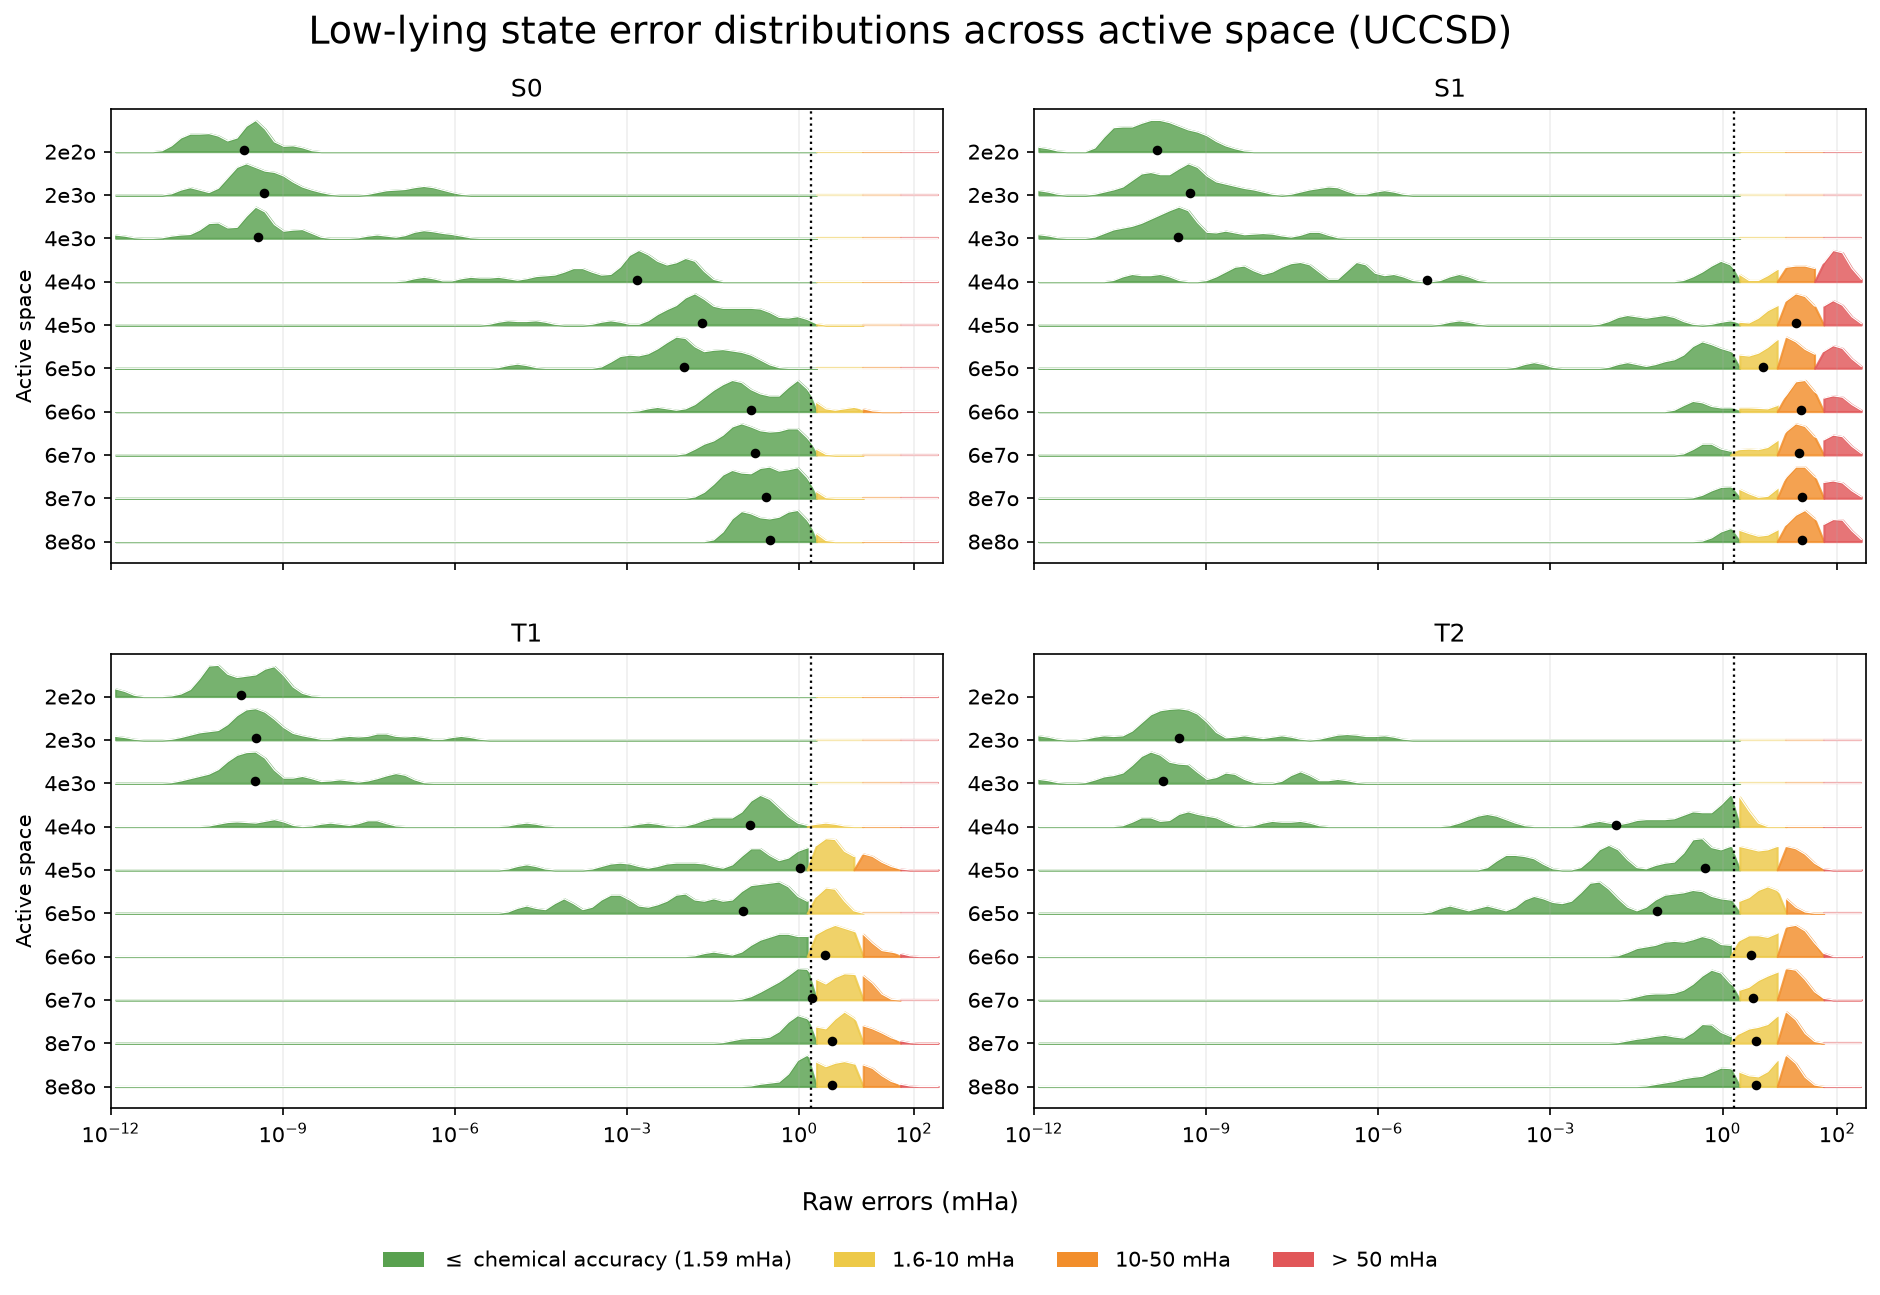

In [10]:
def get_low_state_error_data(df_raw_data):
    states = ["s0", "s1", "t1", "t2"]
    active_spaces = sorted(df_raw_data["active_space"].unique(), key=parse_active_space)

    return {
        active_space: {
            state: df_raw_data.loc[
                df_raw_data["active_space"] == active_space, state
            ].dropna().to_numpy()
            for state in states
        }
        for active_space in active_spaces
    }

uccsd_low_state_error_data = get_low_state_error_data(df_raw_data)

tiered_error_ridgeline_figure = plot_tiered_error_ridgelines(uccsd_low_state_error_data)
save_figure(
    tiered_error_ridgeline_figure,
    "active_space_representability",
    "uccsd_tiered_error_ridgelines",
)
show_scrollable_figs([tiered_error_ridgeline_figure])

In [11]:
def get_low_state_projection_data(df_UCCSD):
    states = ["s0", "s1", "s2", "s3"]
    projection_columns = [f"{state}_projection" for state in states]
    df_singlet = df_UCCSD[df_UCCSD["expansion"] == "singlet"]
    active_spaces = sorted(df_singlet["active_space"].unique(), key=parse_active_space)

    return {
        active_space: (
            df_singlet.loc[
                df_singlet["active_space"] == active_space,
                ["molecule", *projection_columns],
            ]
            .set_index("molecule")
            .reindex(MOLECULE_NAMES)
            .rename(columns=lambda column: column.removesuffix("_projection"))
        )
        for active_space in active_spaces
    }


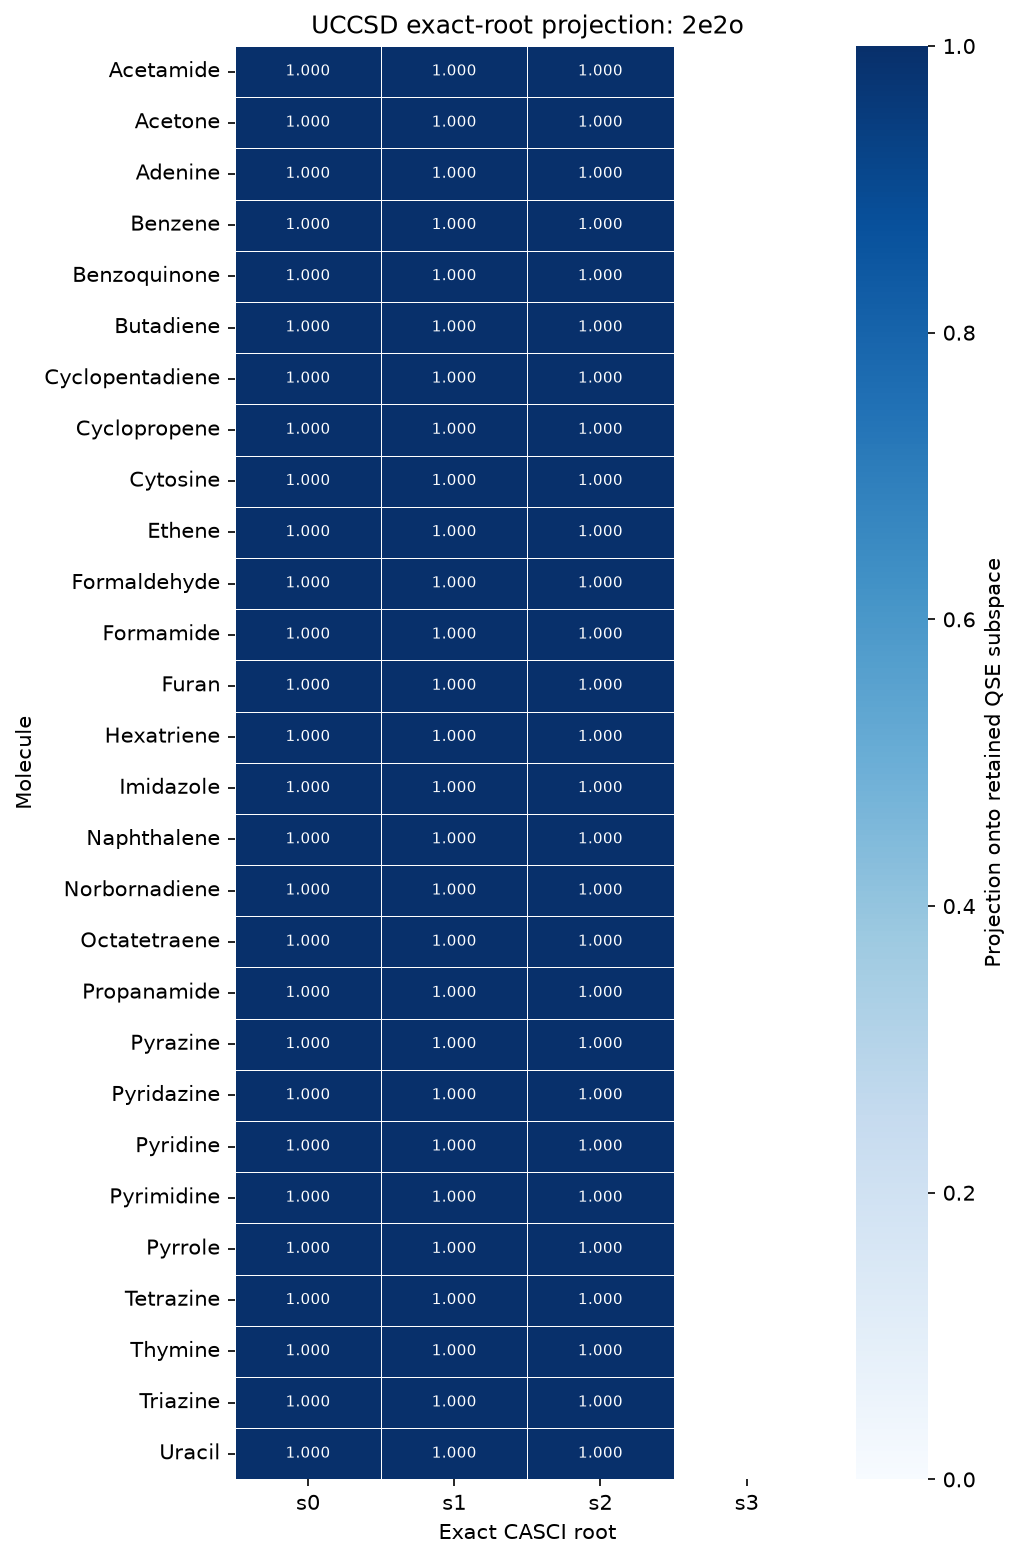
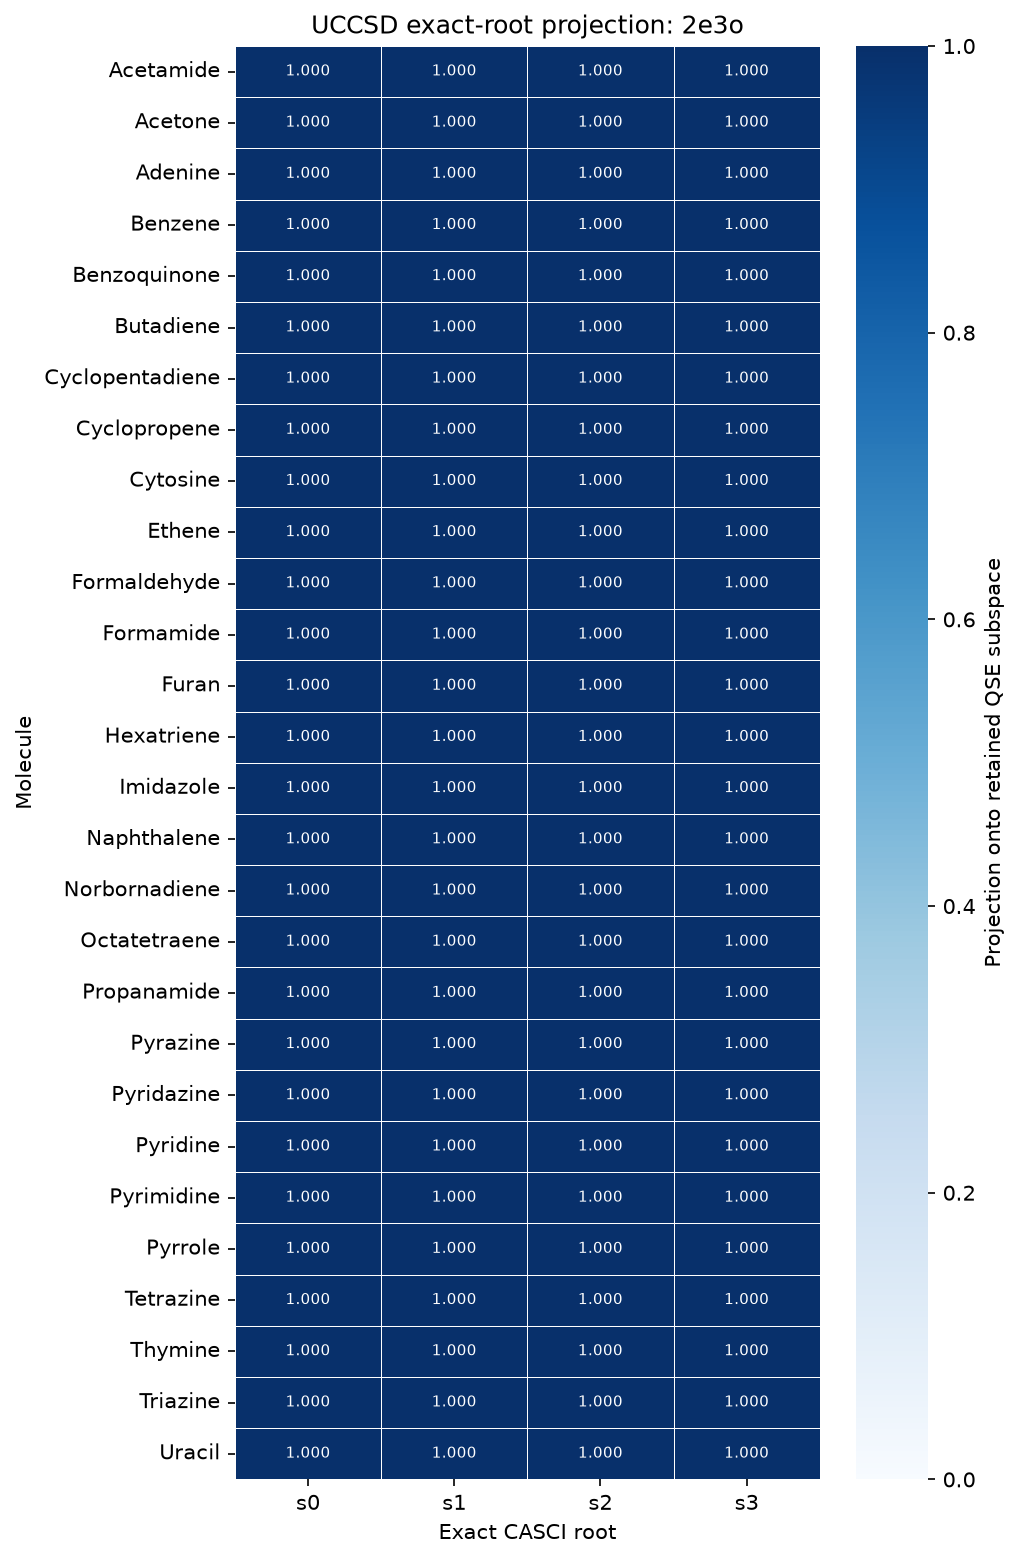
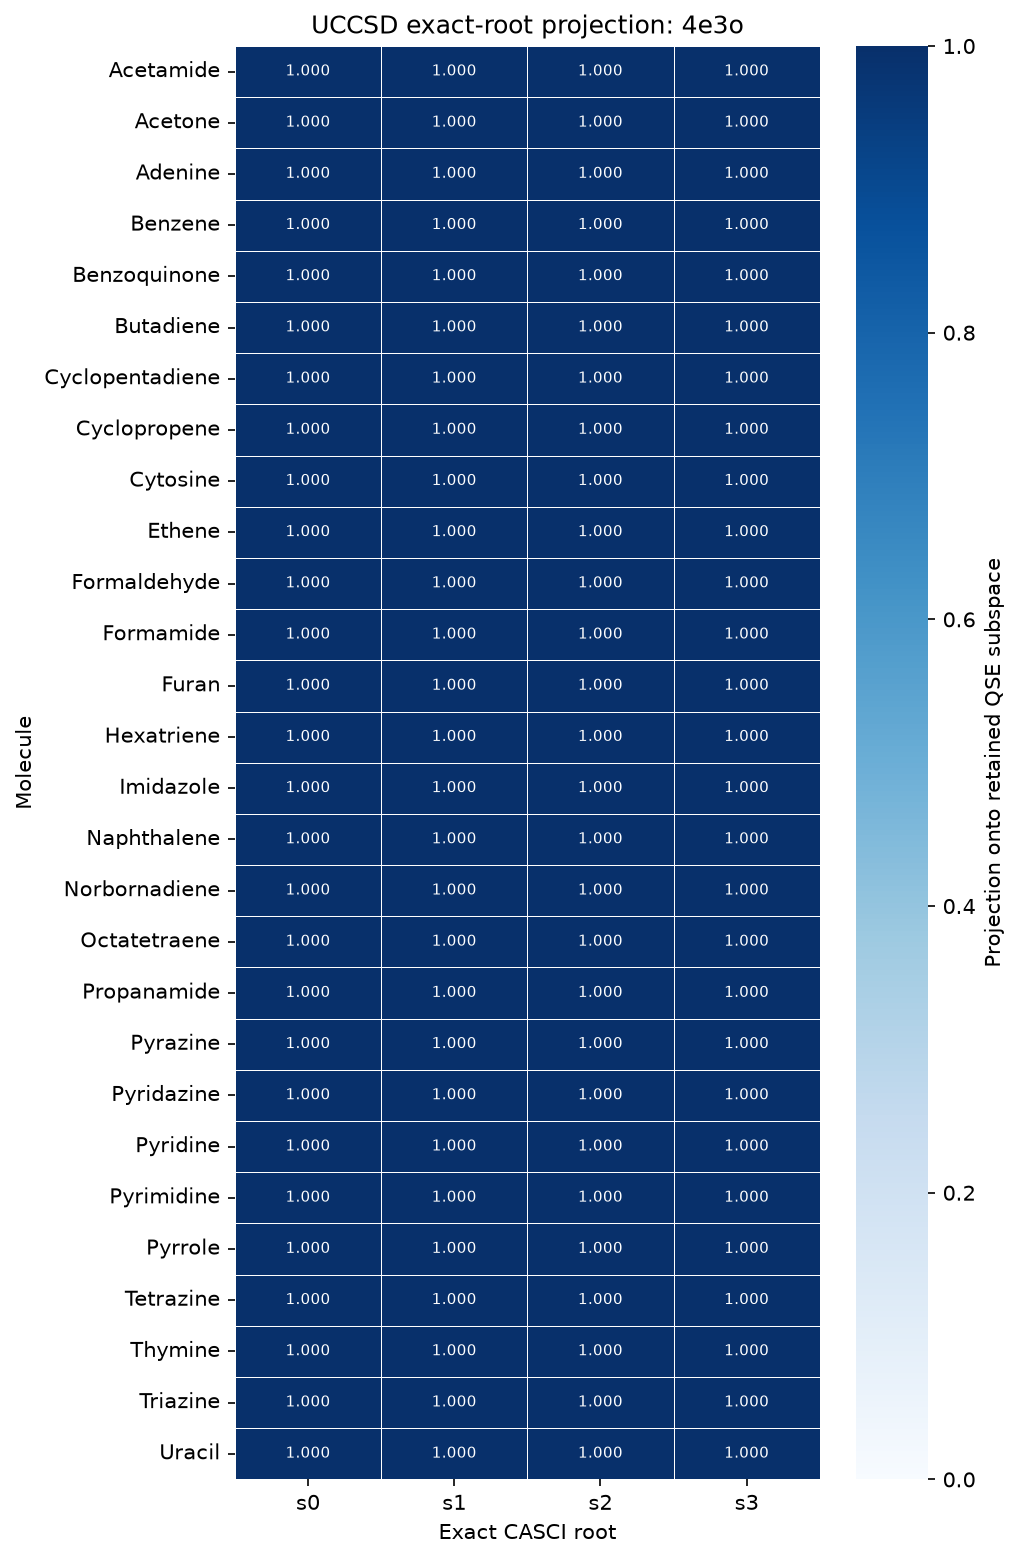
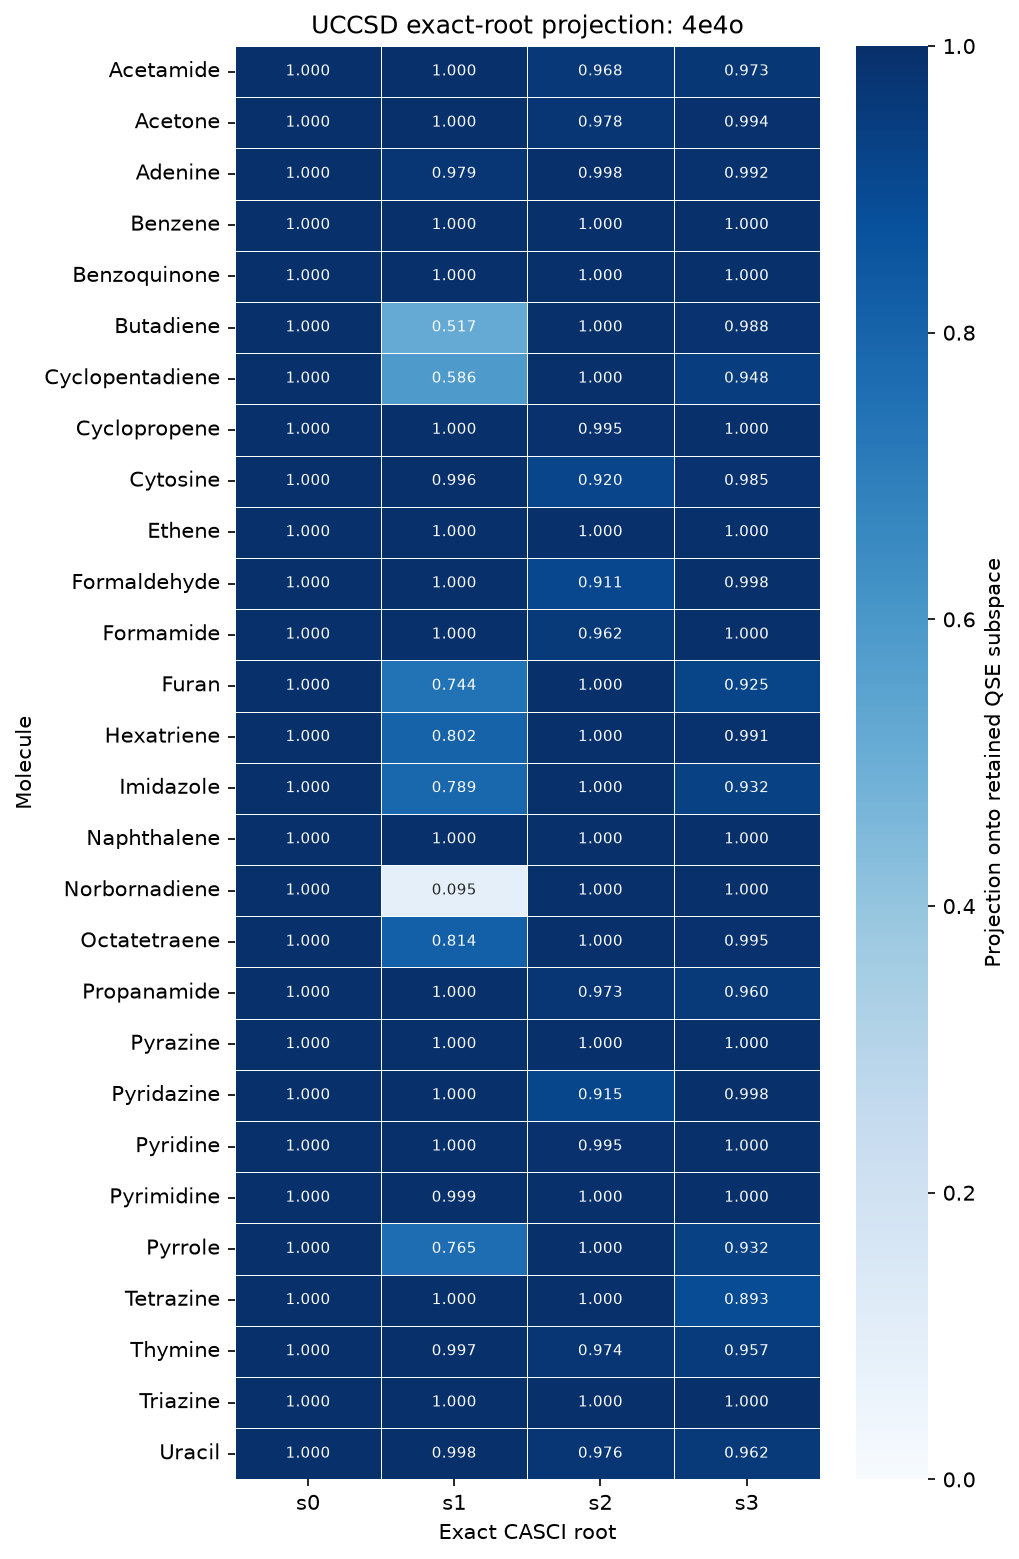
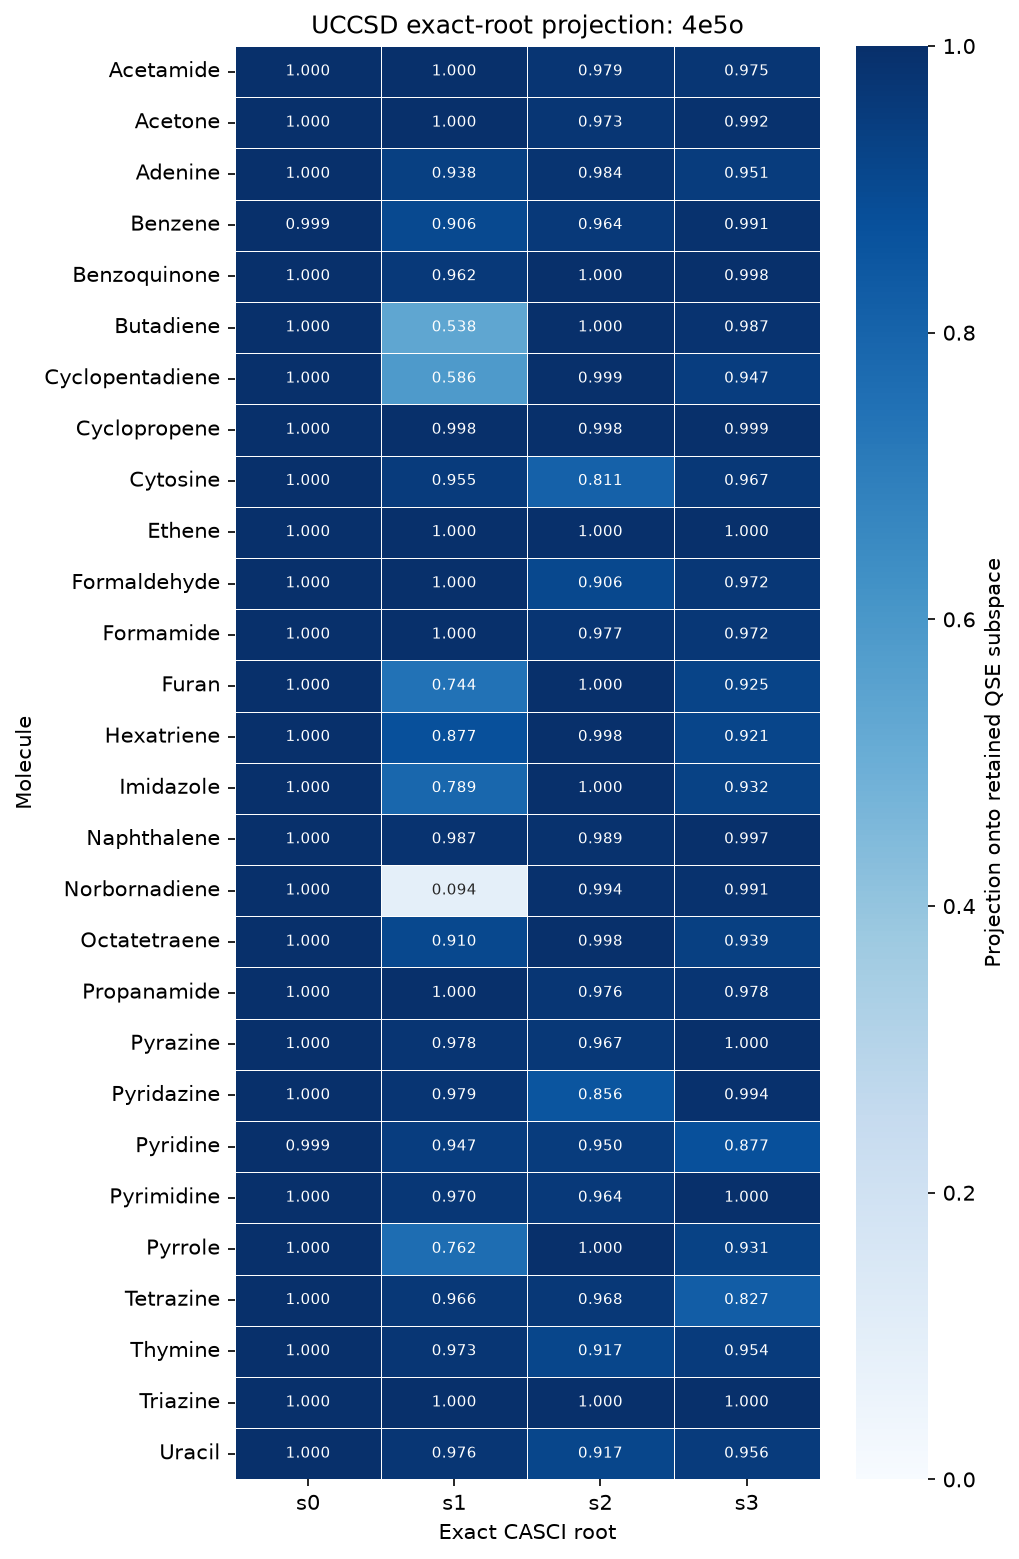
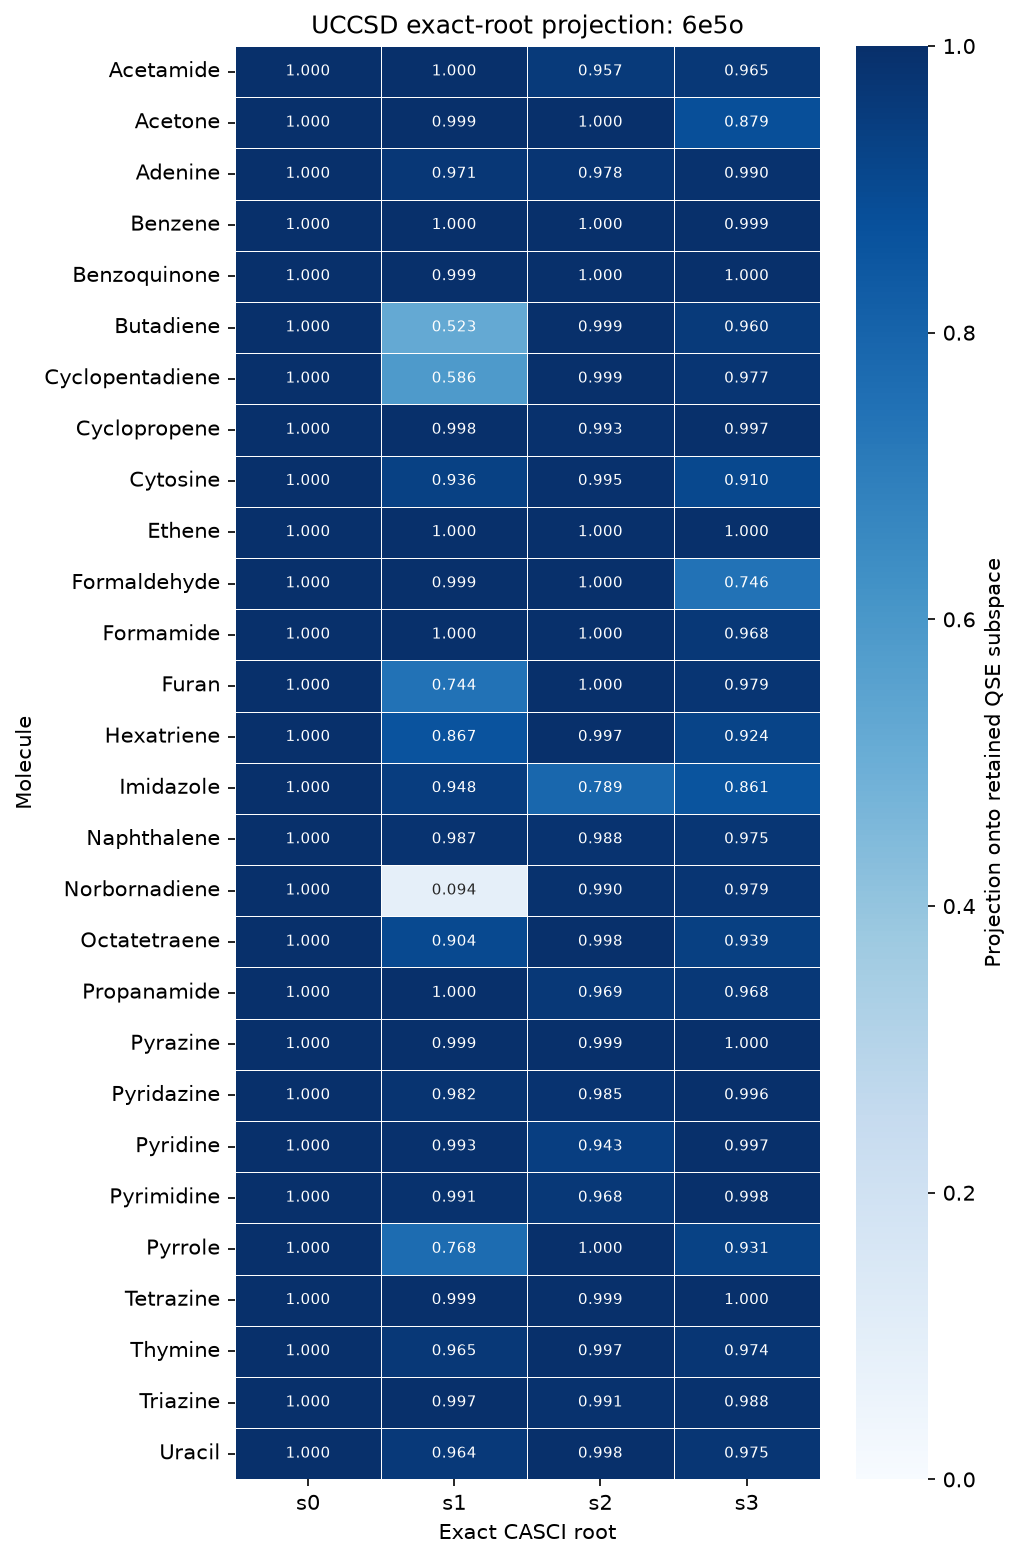
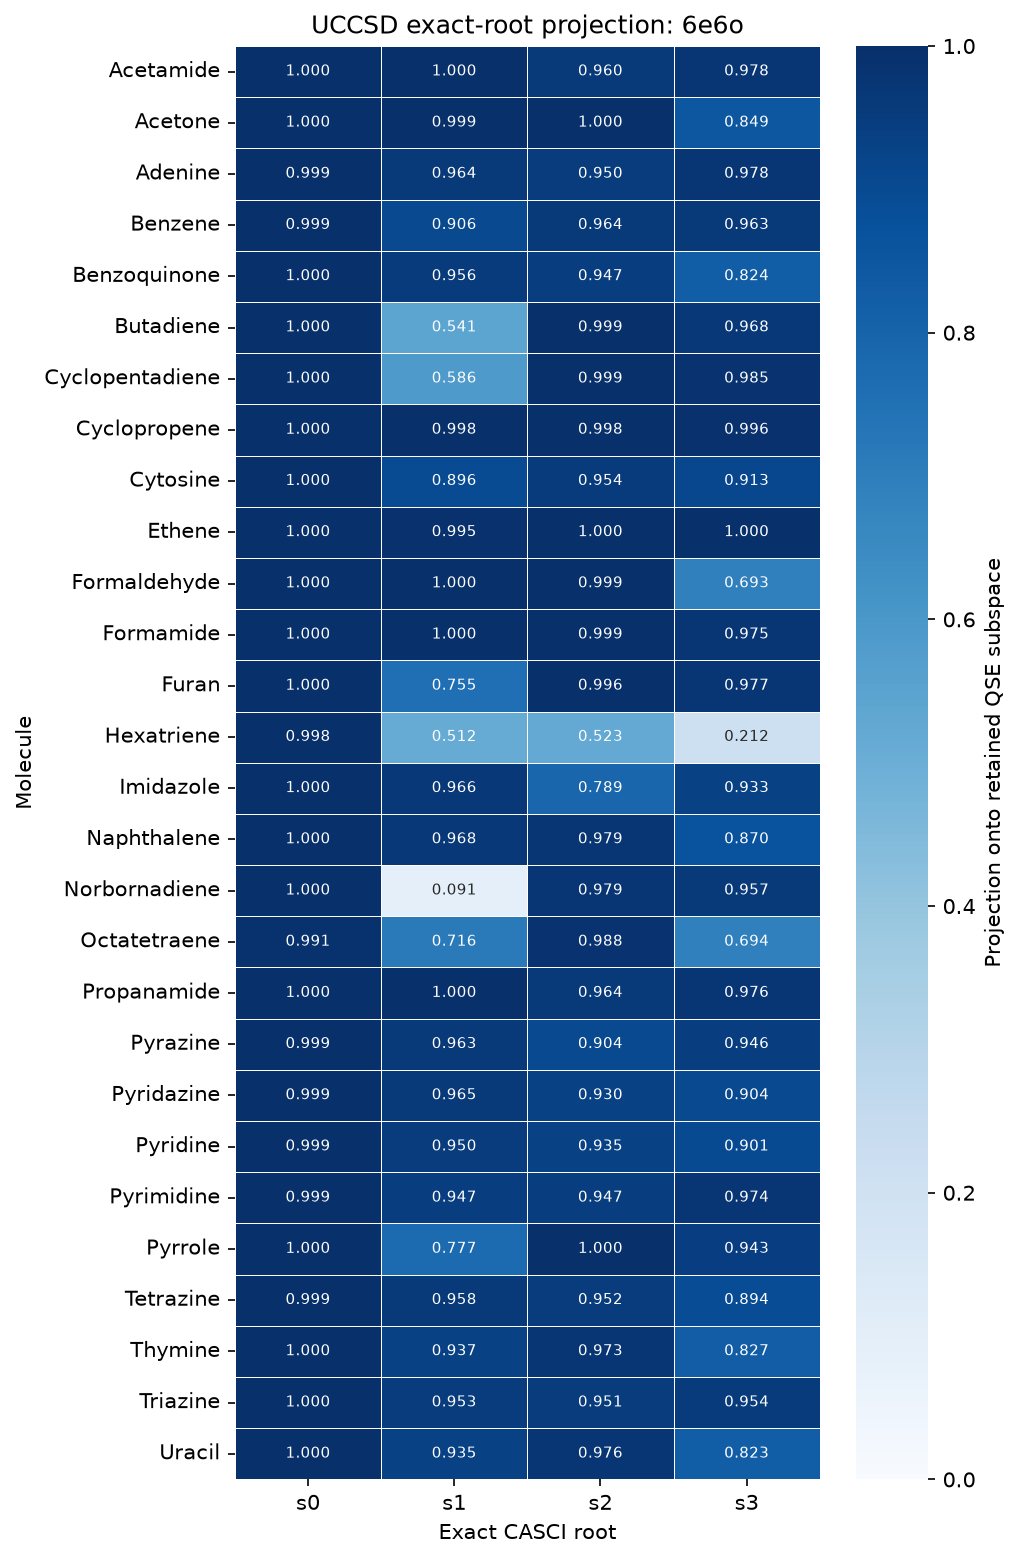
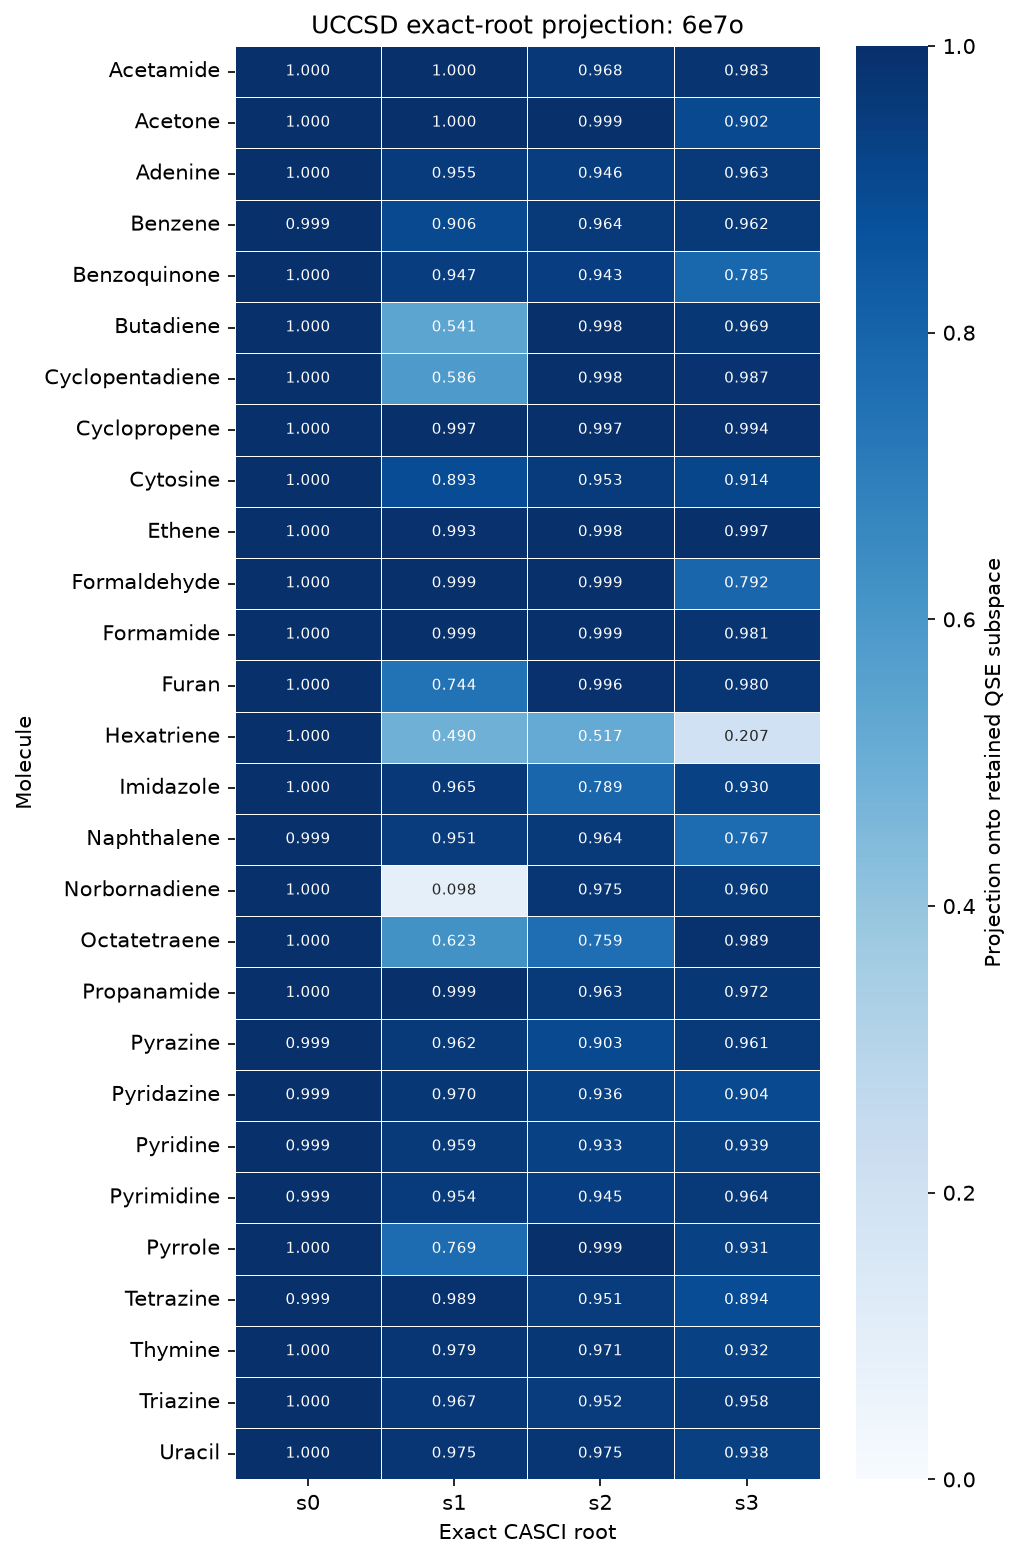
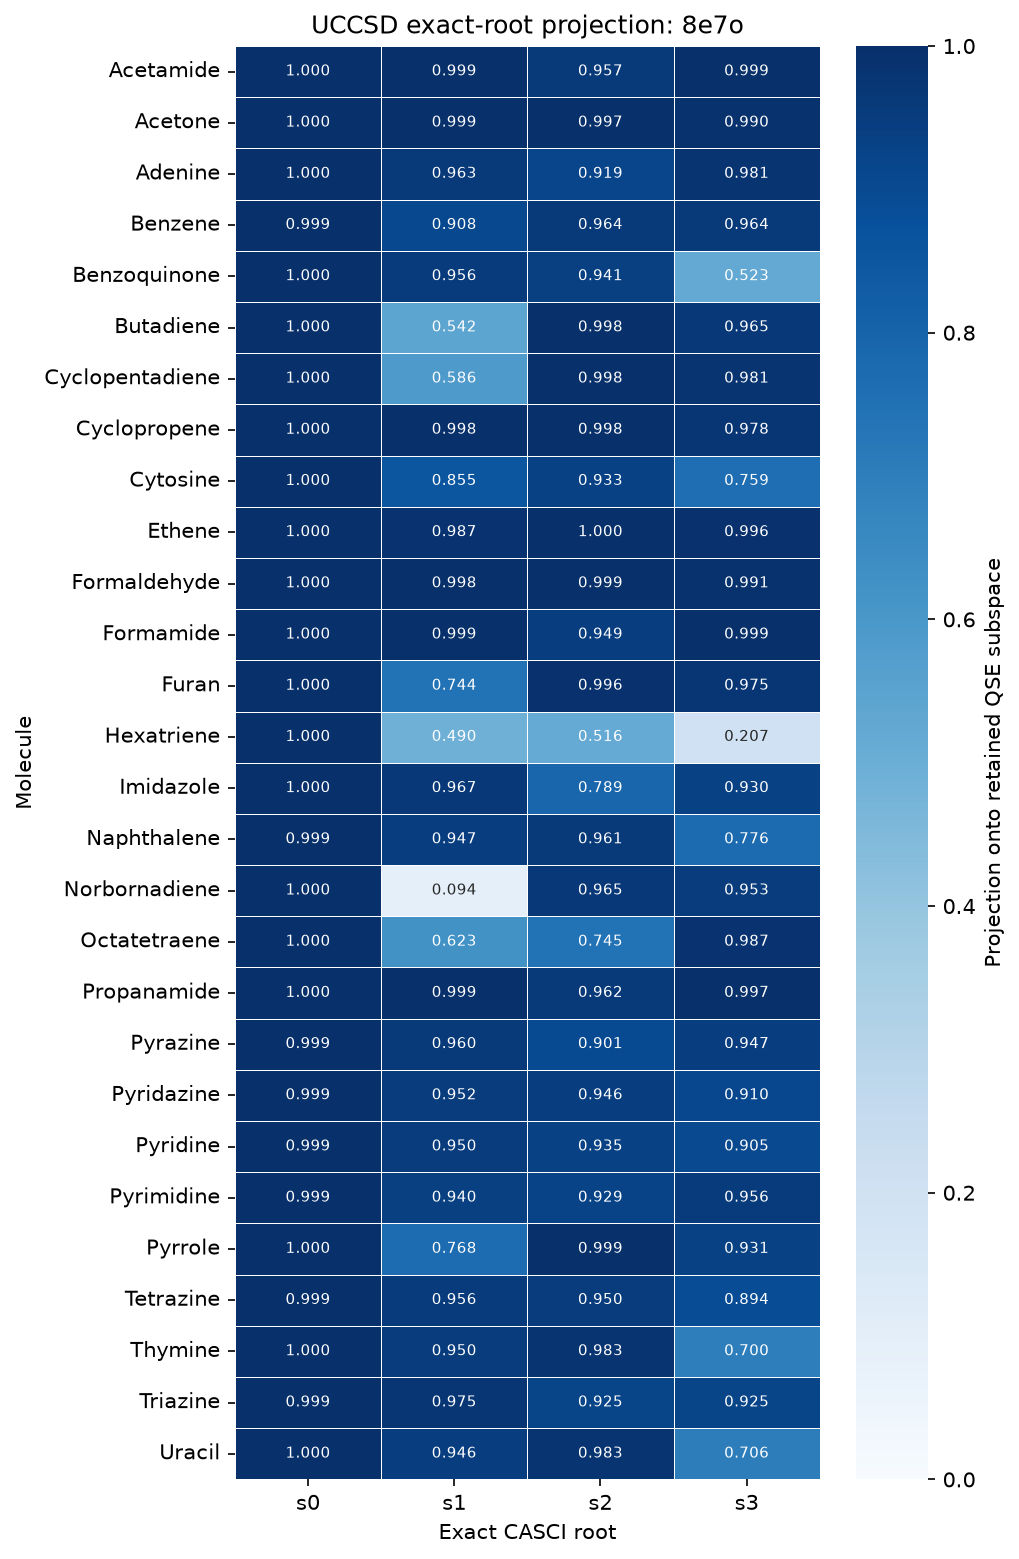
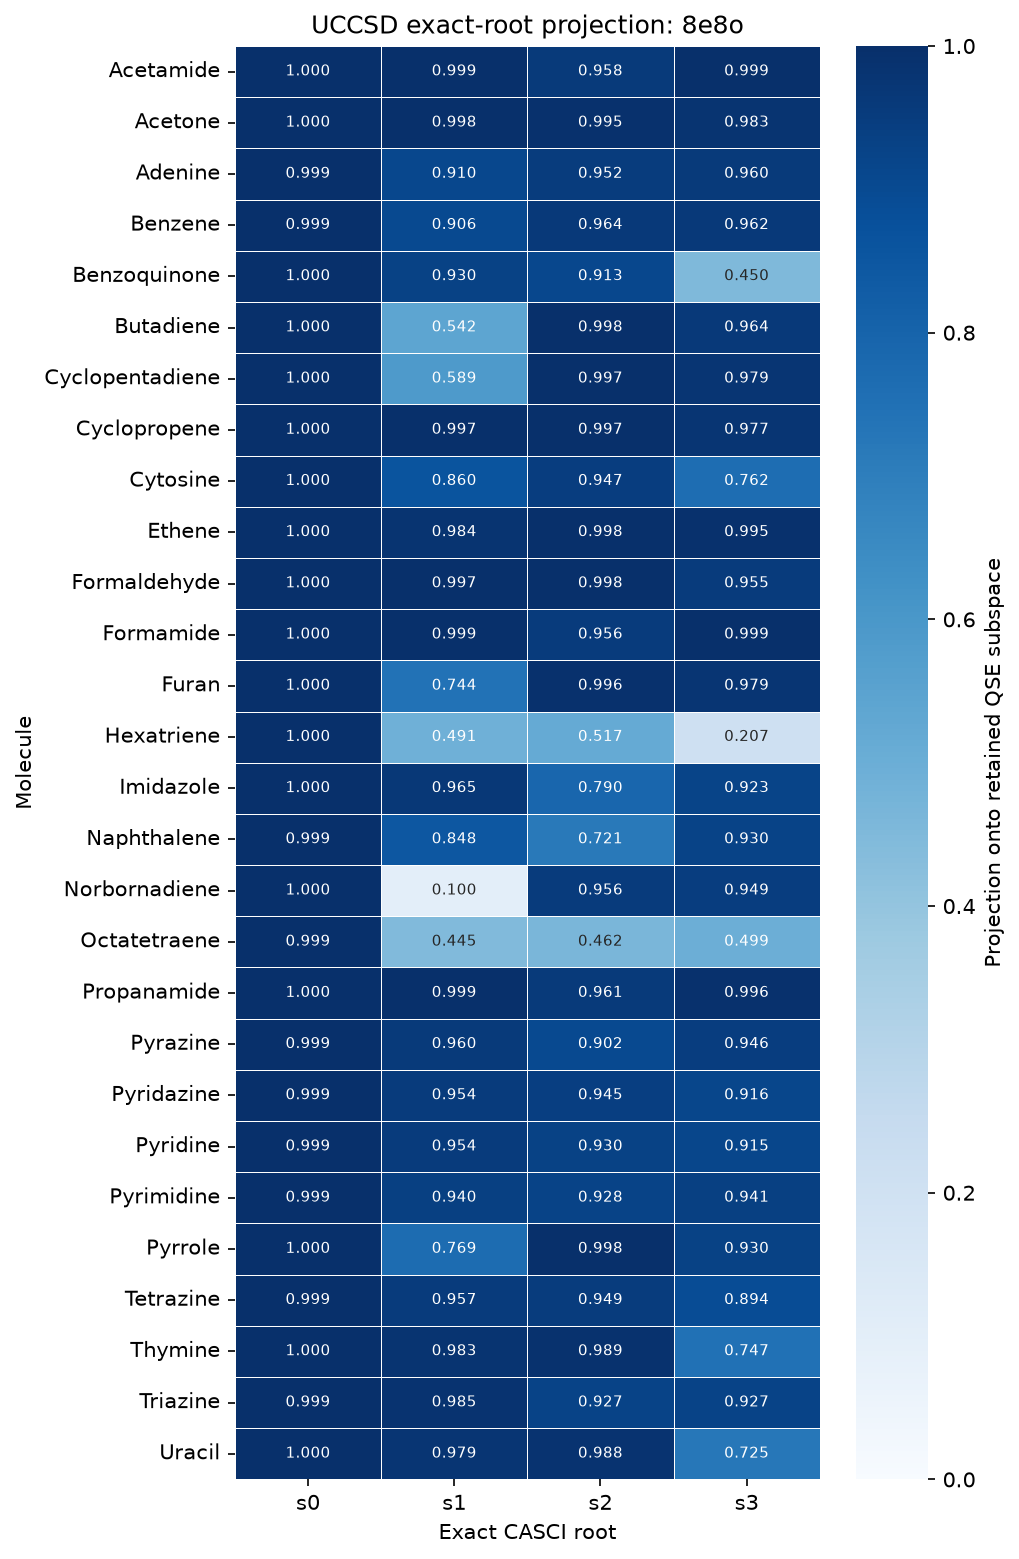

In [12]:
low_state_projection_data = get_low_state_projection_data(df_UCCSD)
low_state_projection_figures = []

for active_space in low_state_projection_data:
    figure = plot_low_state_projection_heatmap(low_state_projection_data, active_space)
    save_figure(
        figure,
        "active_space_representability",
        f"uccsd_low_state_projection_{active_space}",
    )
    low_state_projection_figures.append(figure)

show_scrollable_figs(low_state_projection_figures)

## Ansatz Details

In [13]:
# Compare the number of parameters and circuit depth for each ansatz
# Across all the active space in df_sv
ANSATZ_FUNCTIONS = {
    "1UpCCGSDSinglet": partial(Ansatz_kUpCCGSDSinglet, k=1),
    "2UpCCGSDSinglet": partial(Ansatz_kUpCCGSDSinglet, k=2),
    "3UpCCGSDSinglet": partial(Ansatz_kUpCCGSDSinglet, k=3),
    "UCCSDSinglet": Ansatz_UCCSDSinglet,
    "UCCSD": Ansatz_UCCSD,
    "UCCGSD": Ansatz_UCCGSD,
}
ACTIVE_SPACE_ORDER = sorted(df_sv["active_space"].unique(), key=parse_active_space)
ANSATZ_ORDER = list(ANSATZ_FUNCTIONS)
ANSATZ_PALETTE = dict(zip(ANSATZ_ORDER, sns.color_palette("colorblind", len(ANSATZ_ORDER))))
ANSATZ_LABELS = {ansatz: ansatz for ansatz in ANSATZ_ORDER}


def get_ansatz_complexity(active_space, ansatz_name):
    """
    Runs qibochem Ansatz to get the params and circuit depth
    Builds a molecule like object with same attributes to parse into Ansatz
    """
    num_e, num_o = parse_active_space(active_space)
    molecule = SimpleNamespace(nelec=num_e, nso=2 * num_o, n_active_e=None, n_active_orbs=None)
    ansatz = ANSATZ_FUNCTIONS[ansatz_name](molecule, use_mp2_guess=False)

    return len(ansatz.param_names), ansatz.circuit.depth


ansatz_complexity = []
# Plot for all active spaces in df_sv and all ansatz types
for active_space in sorted(df_sv["active_space"].unique(), key=parse_active_space):
    for ansatz_name in ANSATZ_FUNCTIONS:
        num_parameters, circuit_depth = get_ansatz_complexity(active_space, ansatz_name)
        ansatz_complexity.append({
            "active_space": active_space,
            "ansatz": ansatz_name,
            "num_parameters": num_parameters,
            "circuit_depth": circuit_depth,
        })

df_ansatz_complexity = pd.DataFrame(ansatz_complexity)


KeyboardInterrupt: 

## Low-lying States

In [ ]:
def show_low_lying_state_errors(active_space, df_sv):
    """
    Filter for each active space and separate by ansatz
    """
    states = ["s0", "s1", "t1", "t2"]
    df_active = df_sv[df_sv["active_space"] == active_space]
    errors = {}

    for ansatz in ANSATZ_FUNCTIONS:
        df_active_ansatz = df_active[df_active["ansatz"] == ansatz]
        errors[ansatz] = {
            state: df_active_ansatz[f"{state}_error"].dropna().to_numpy()
            for state in states
        }

    df_median = pd.DataFrame({
        ansatz: {state: np.median(values) for state, values in state_errors.items()}
        for ansatz, state_errors in errors.items()
    }).T

    return errors, df_median

/opt/miniconda3/envs/qse-qibochem/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3862: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/miniconda3/envs/qse-qibochem/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)



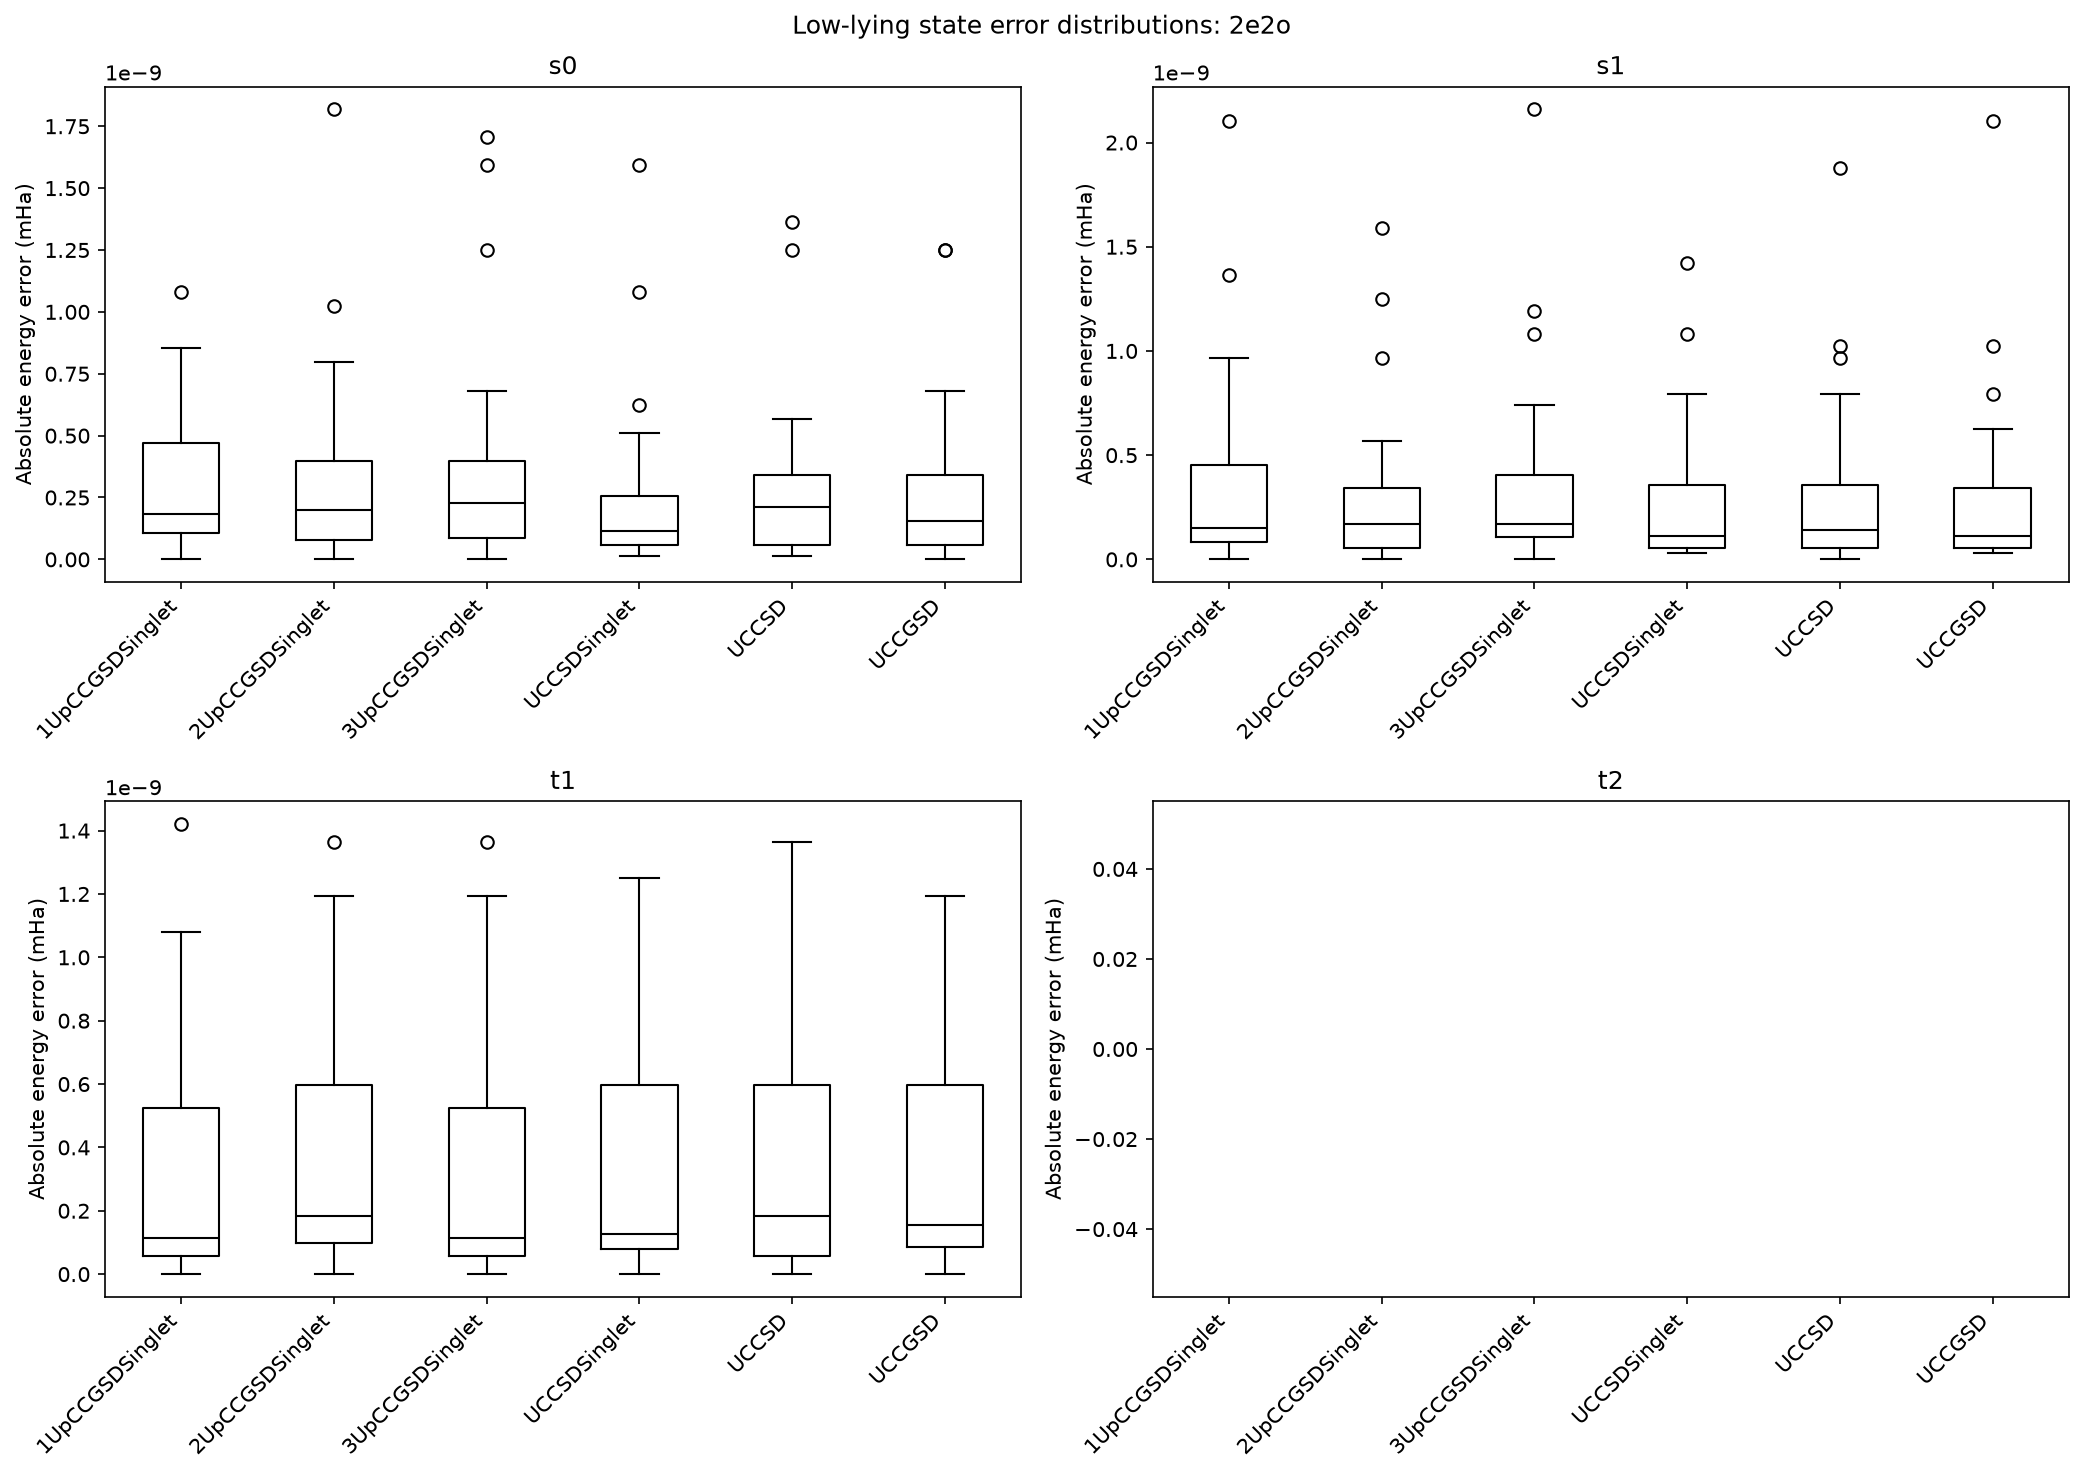
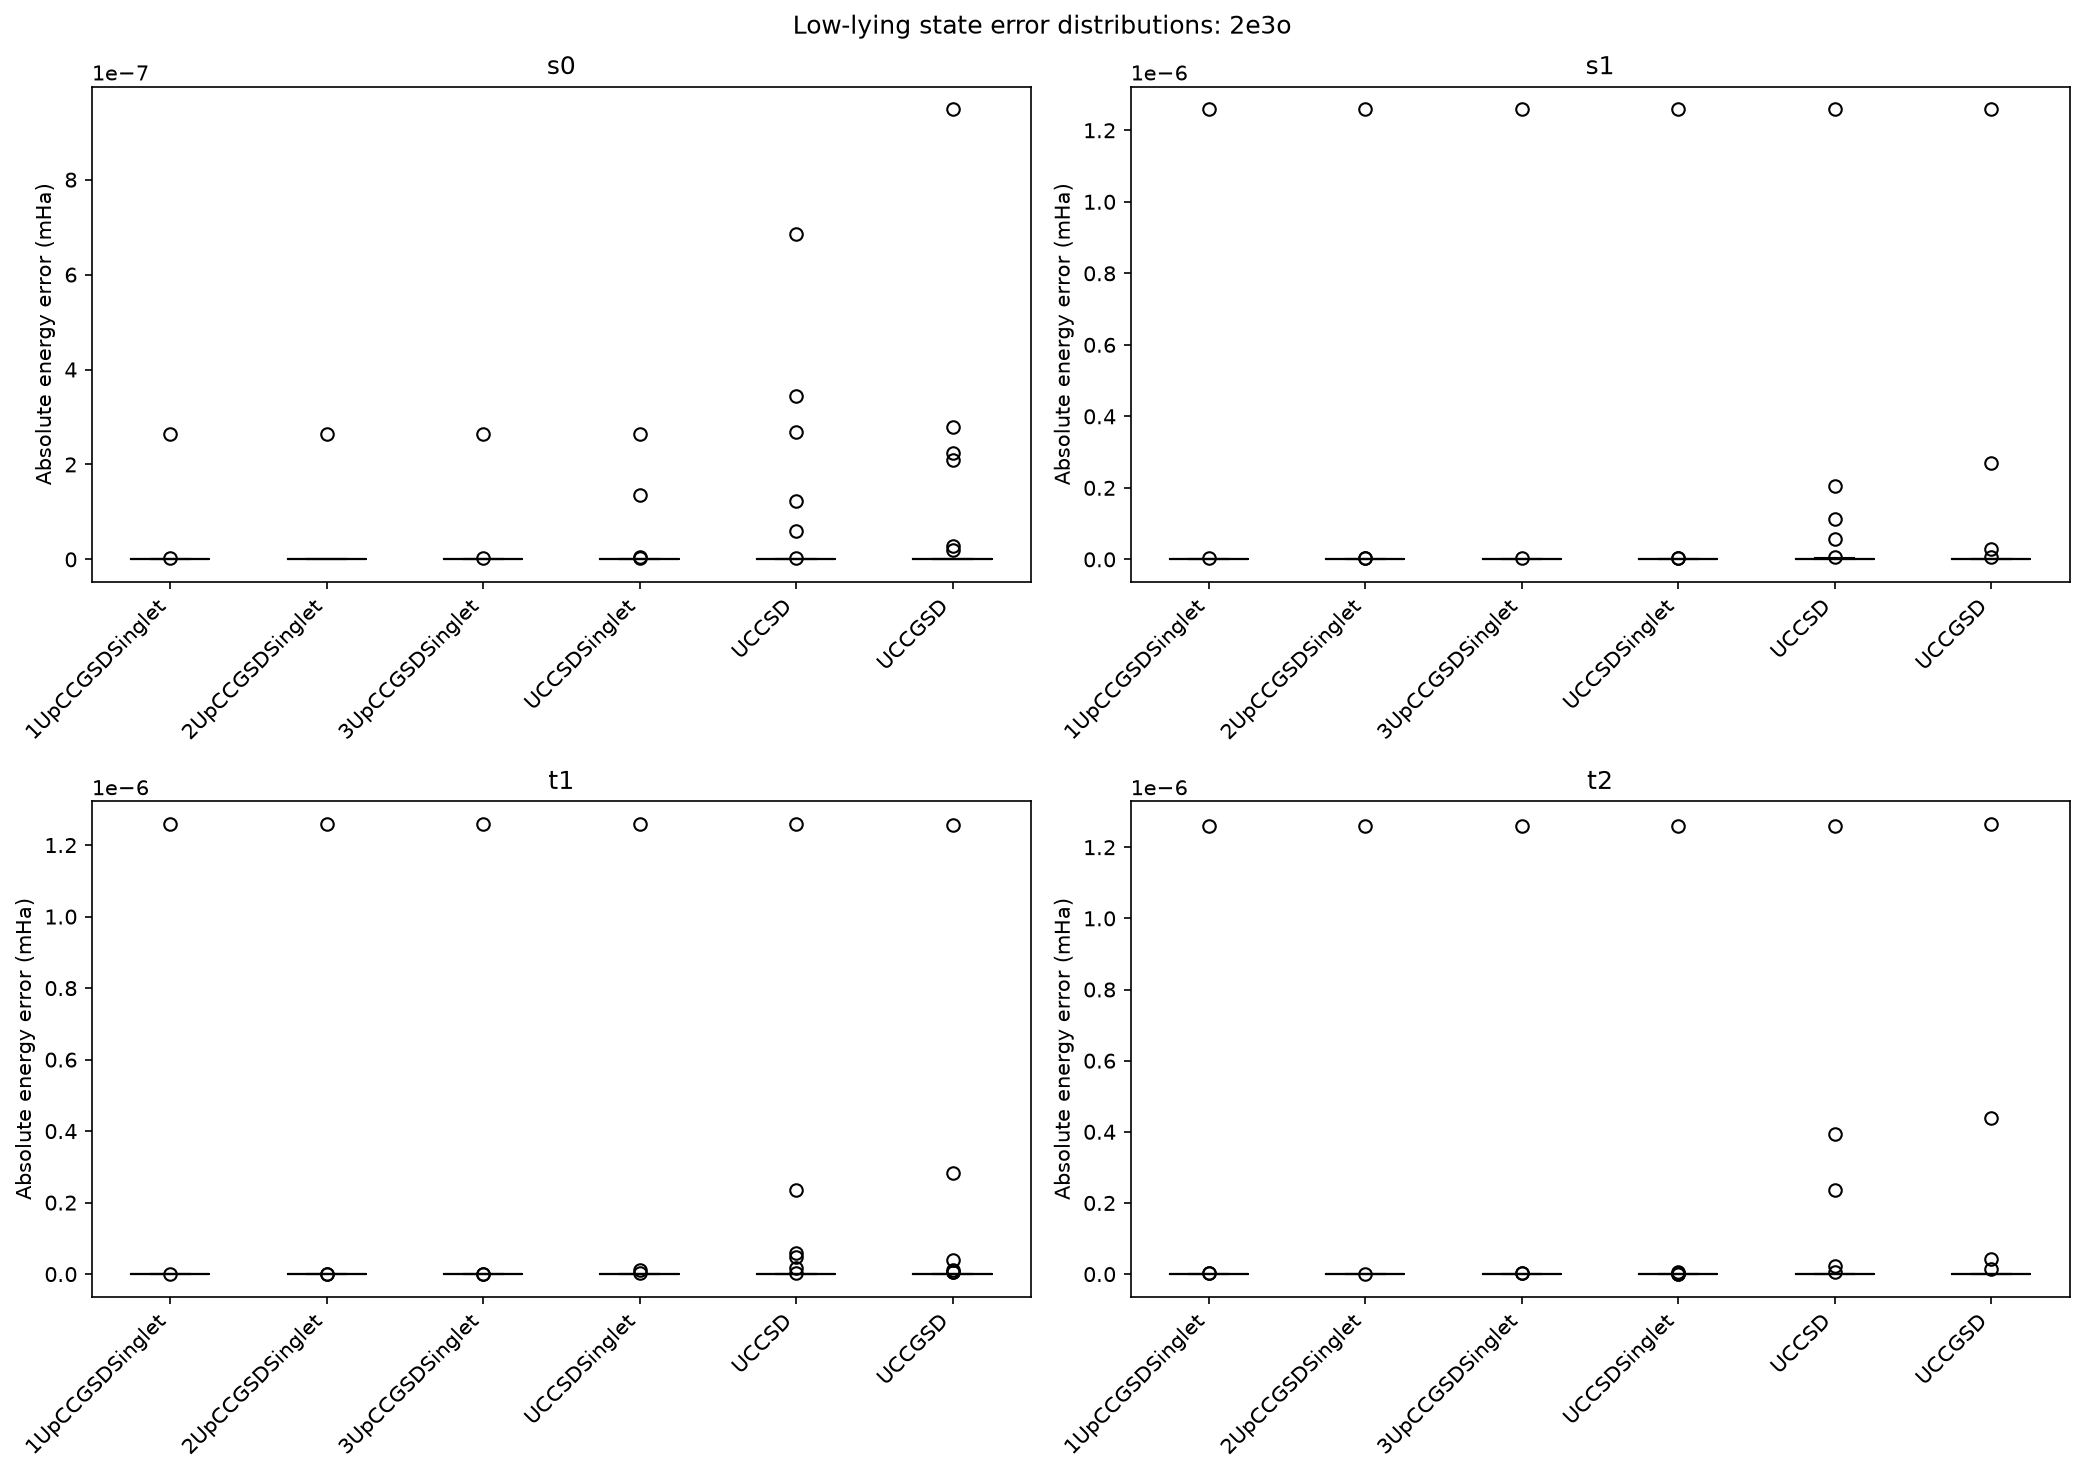
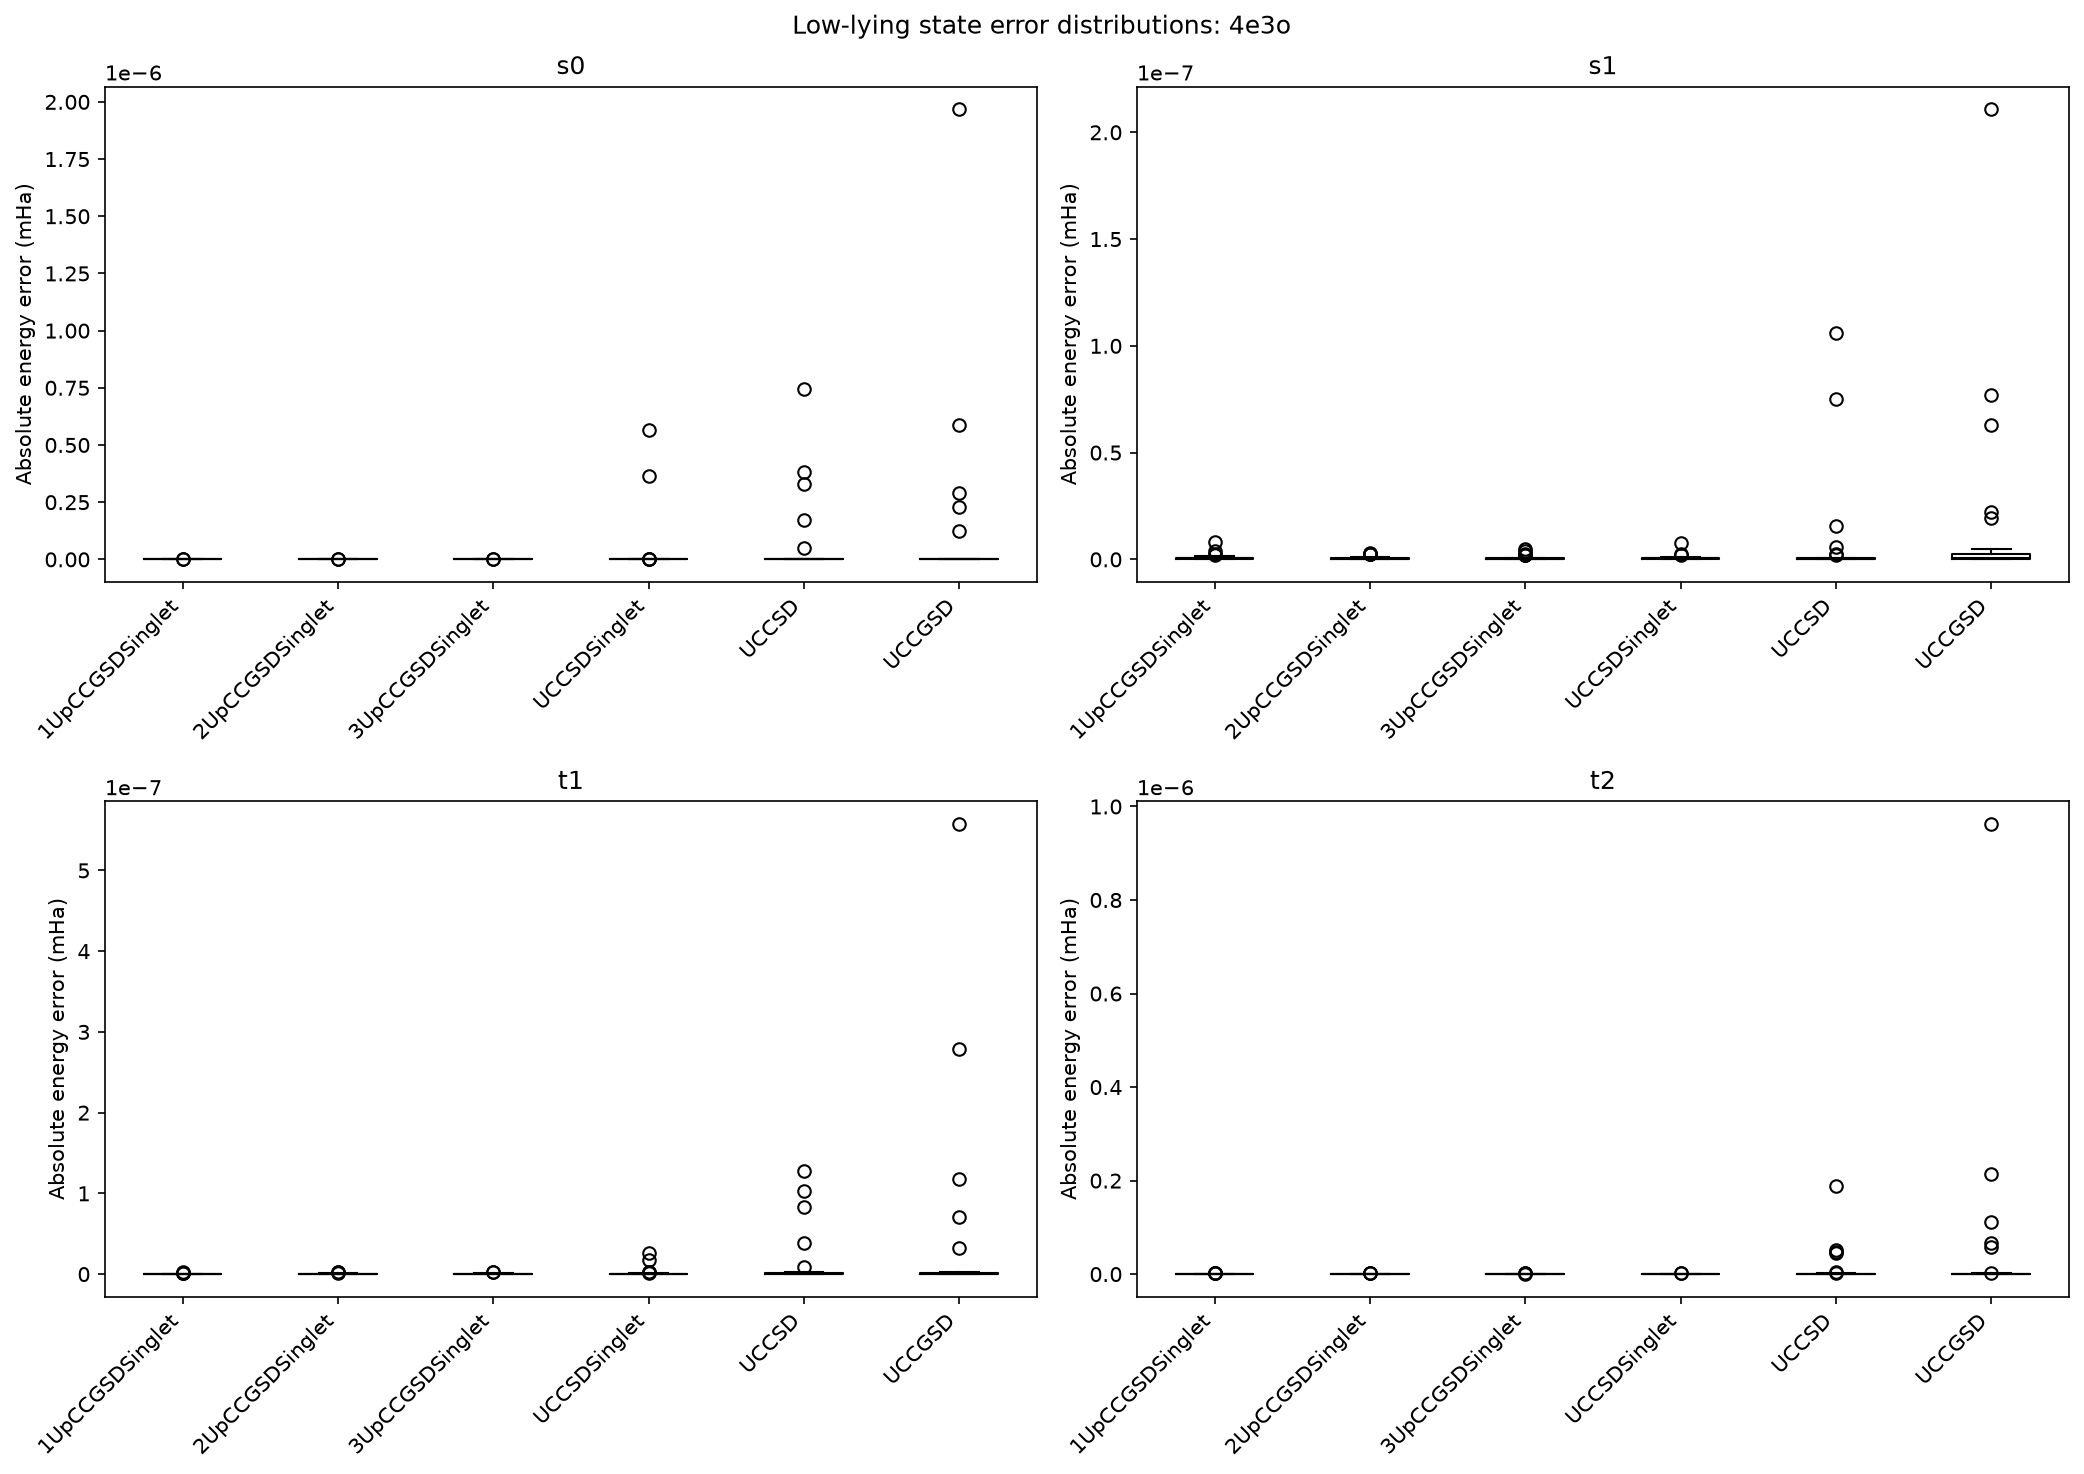
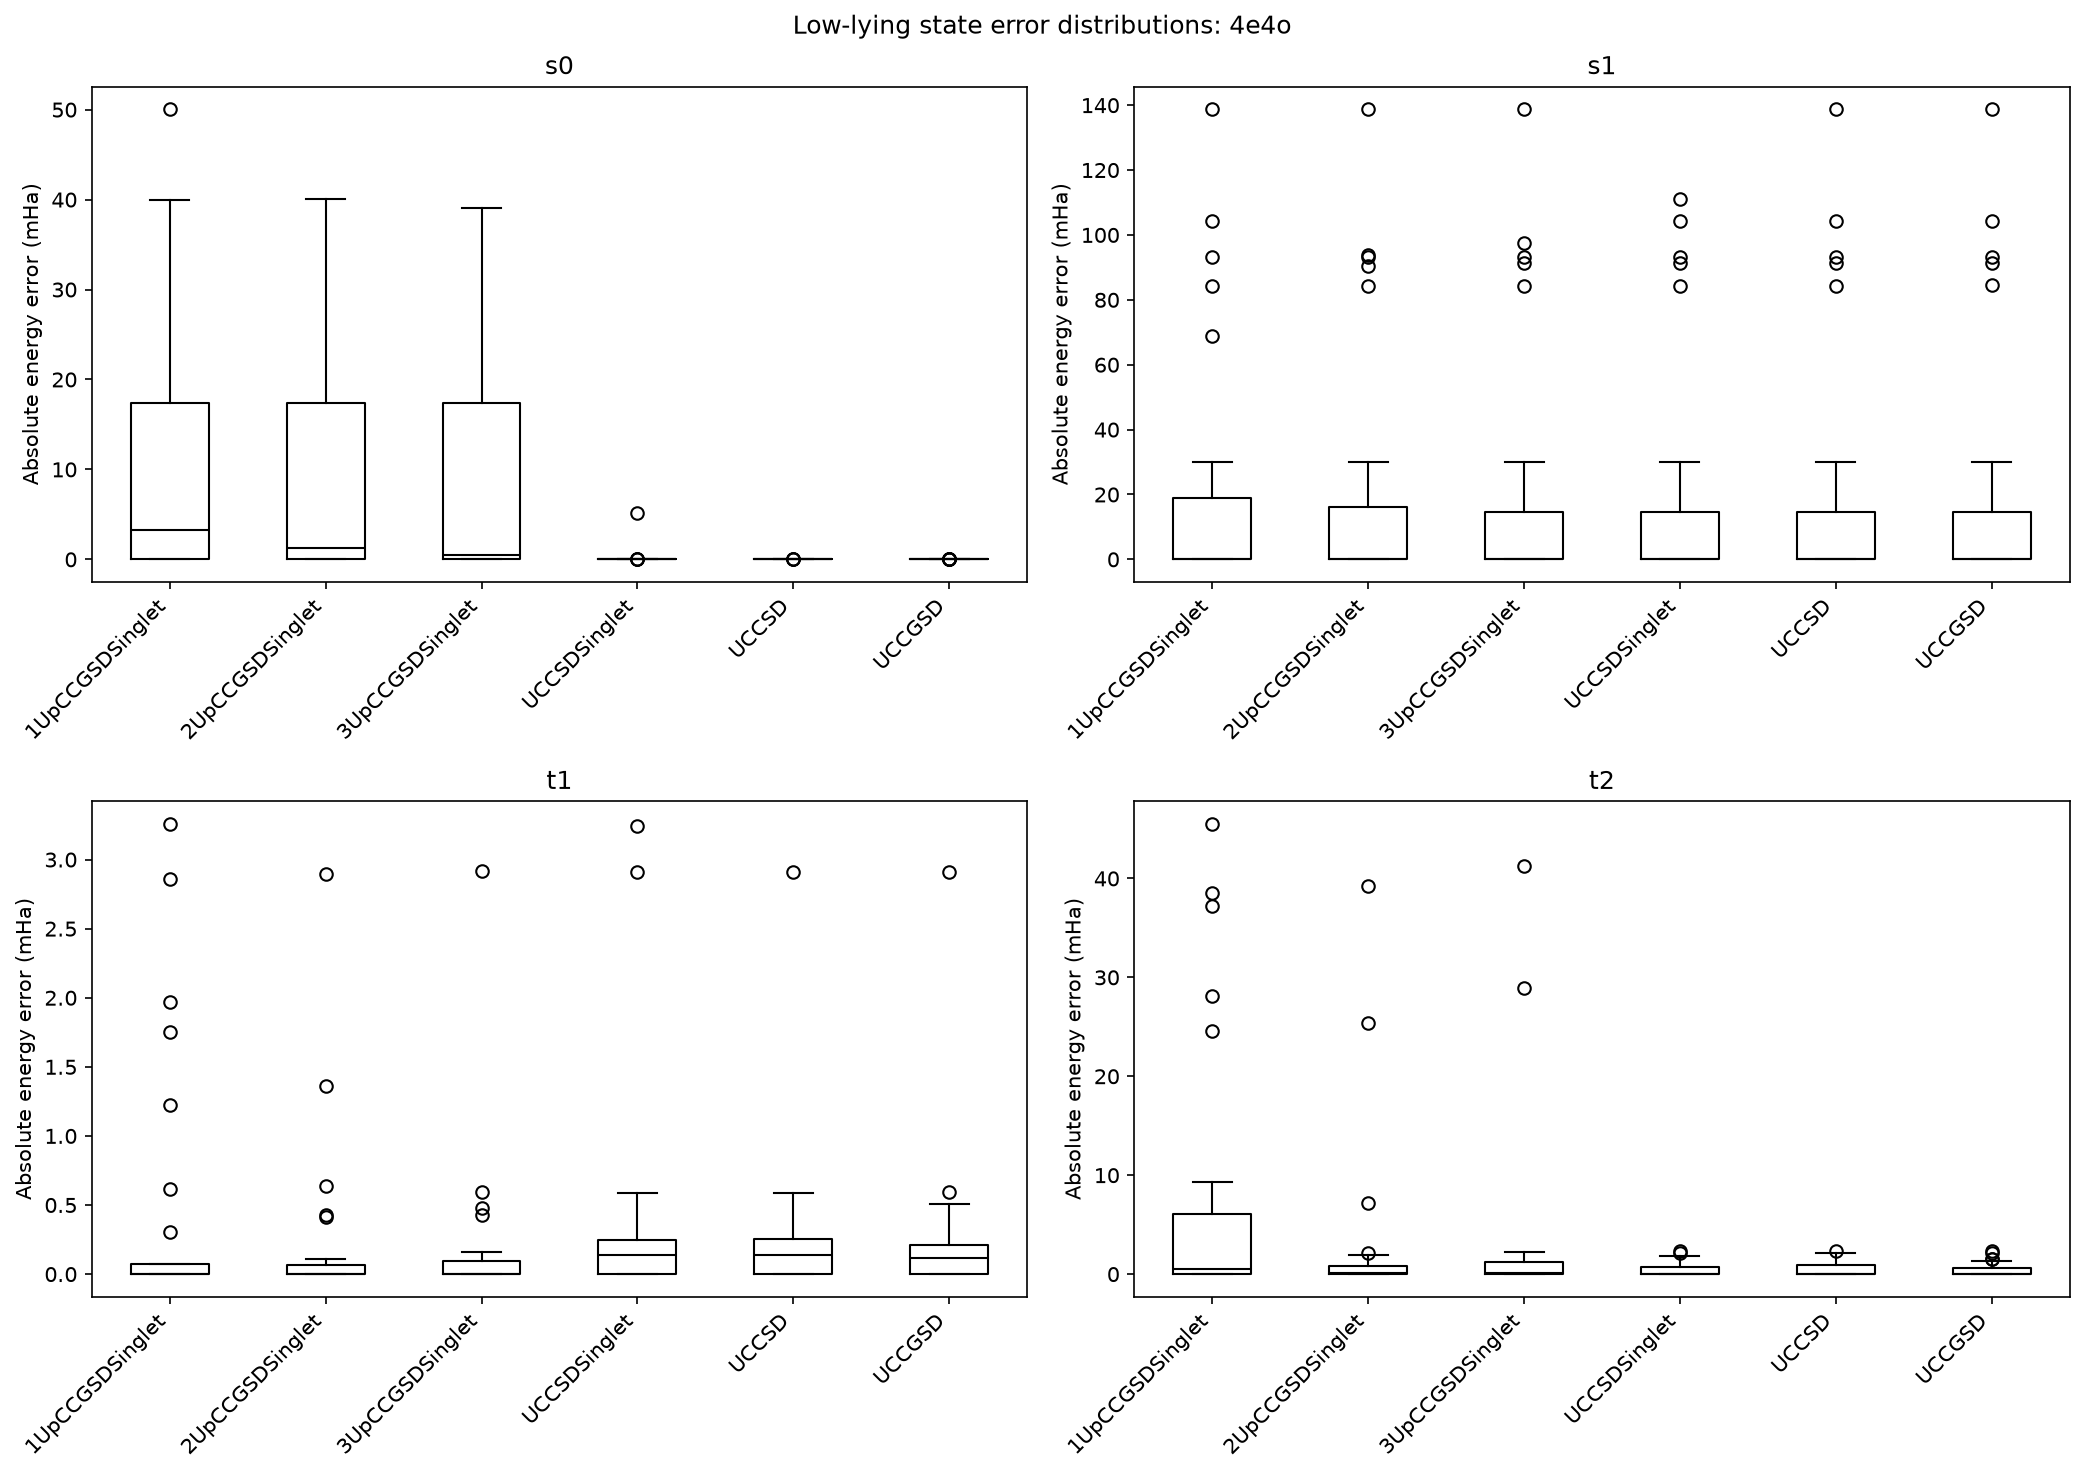
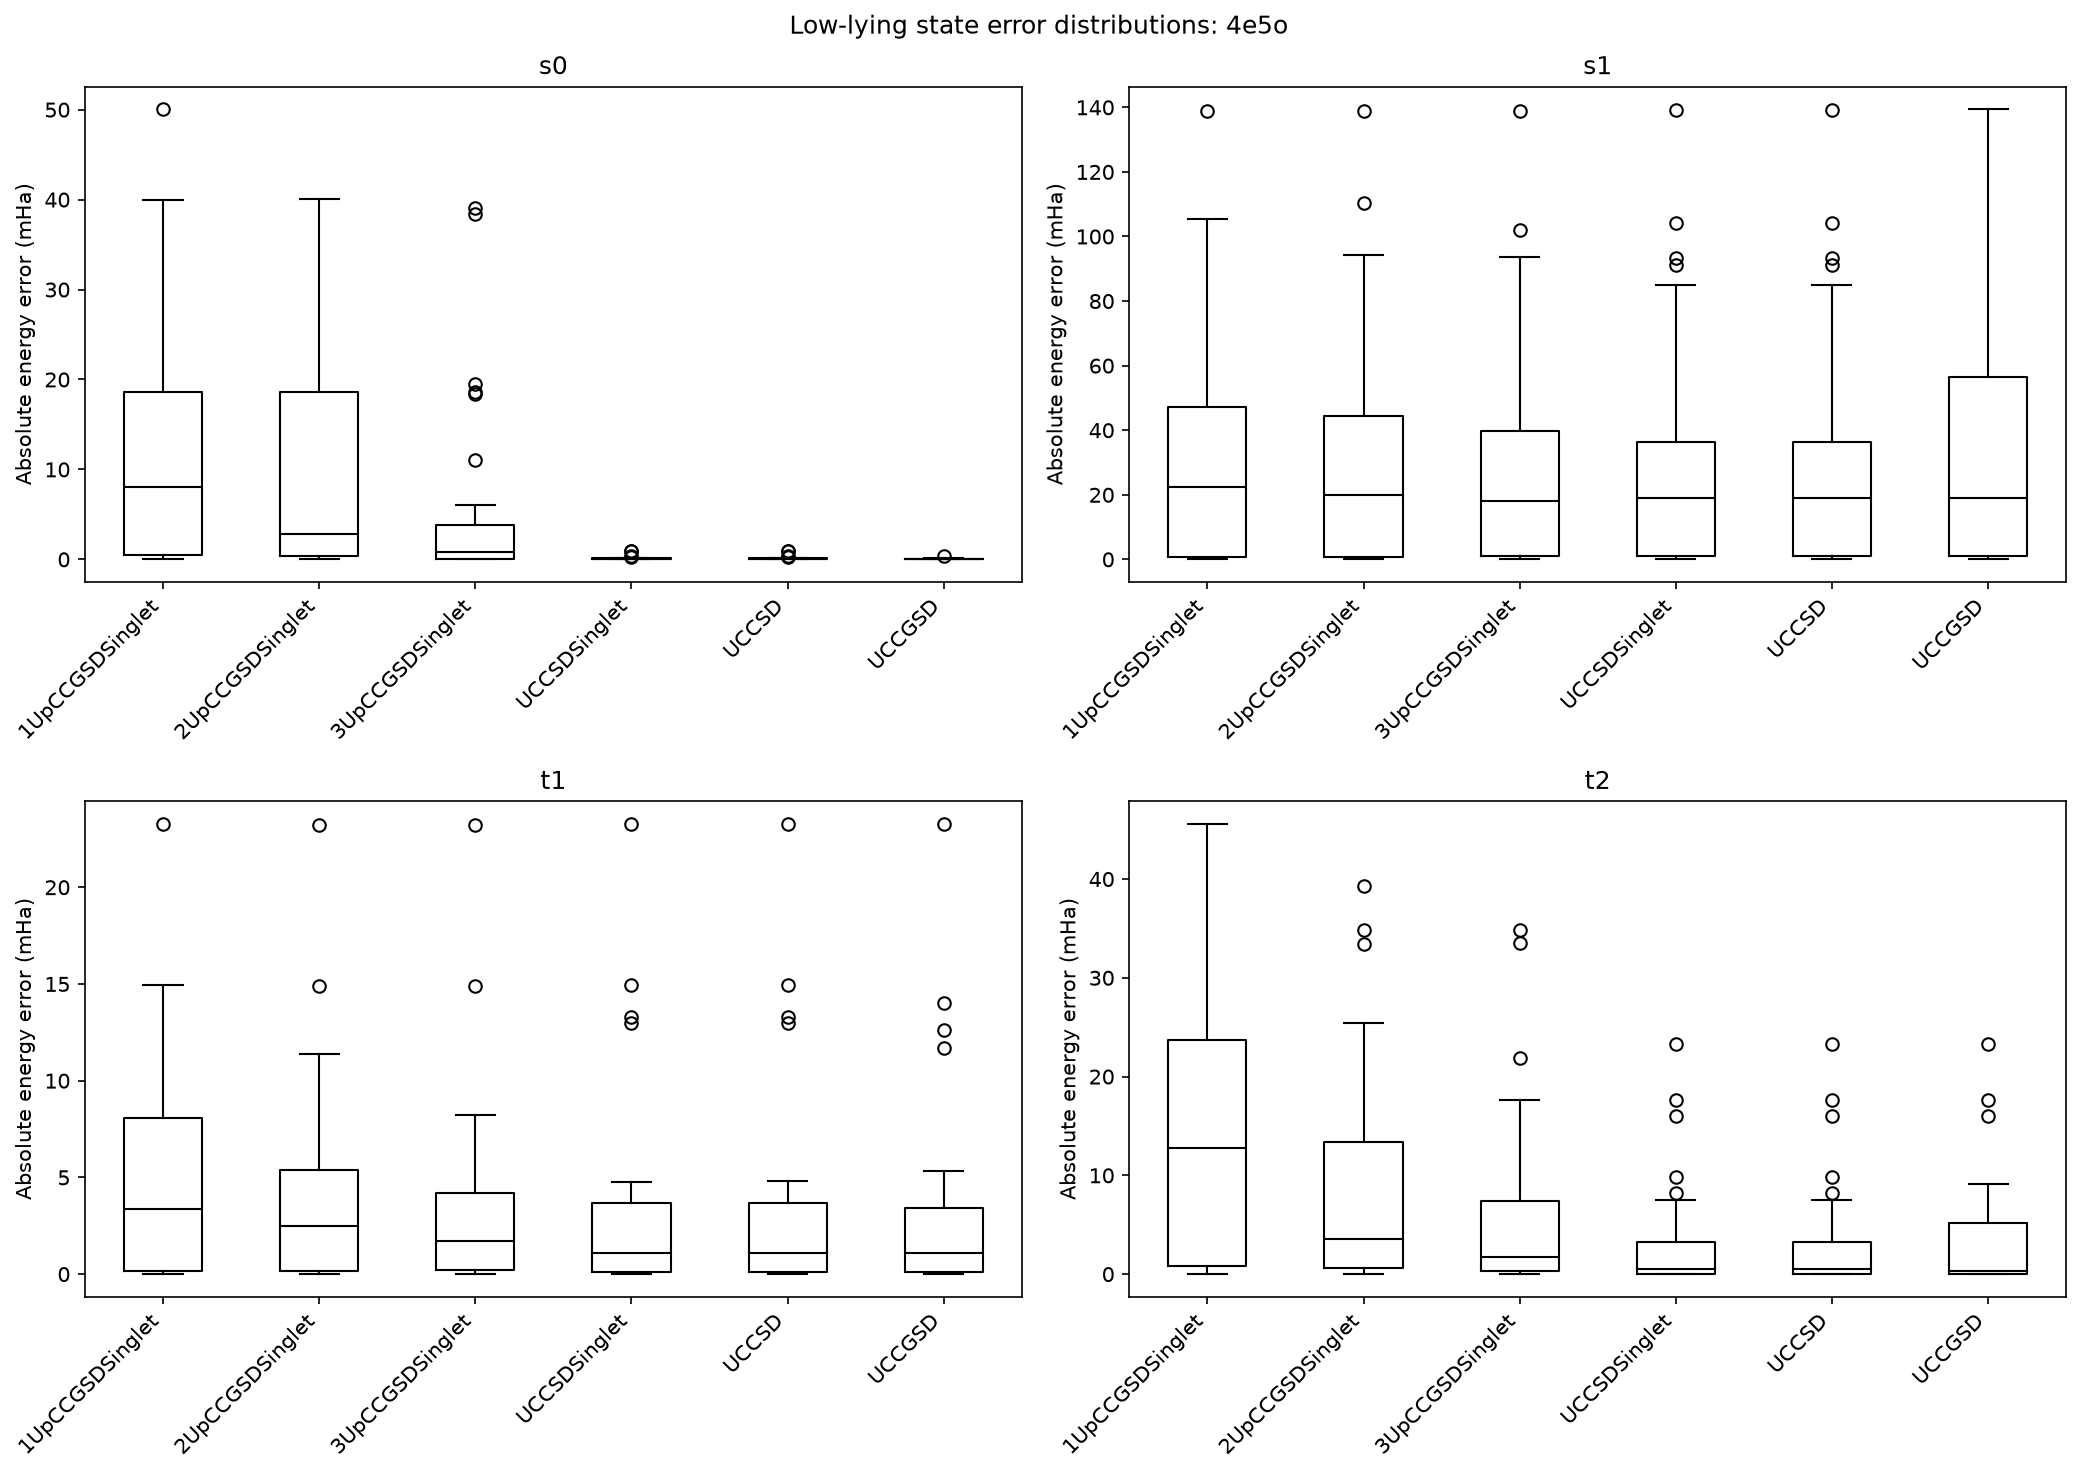
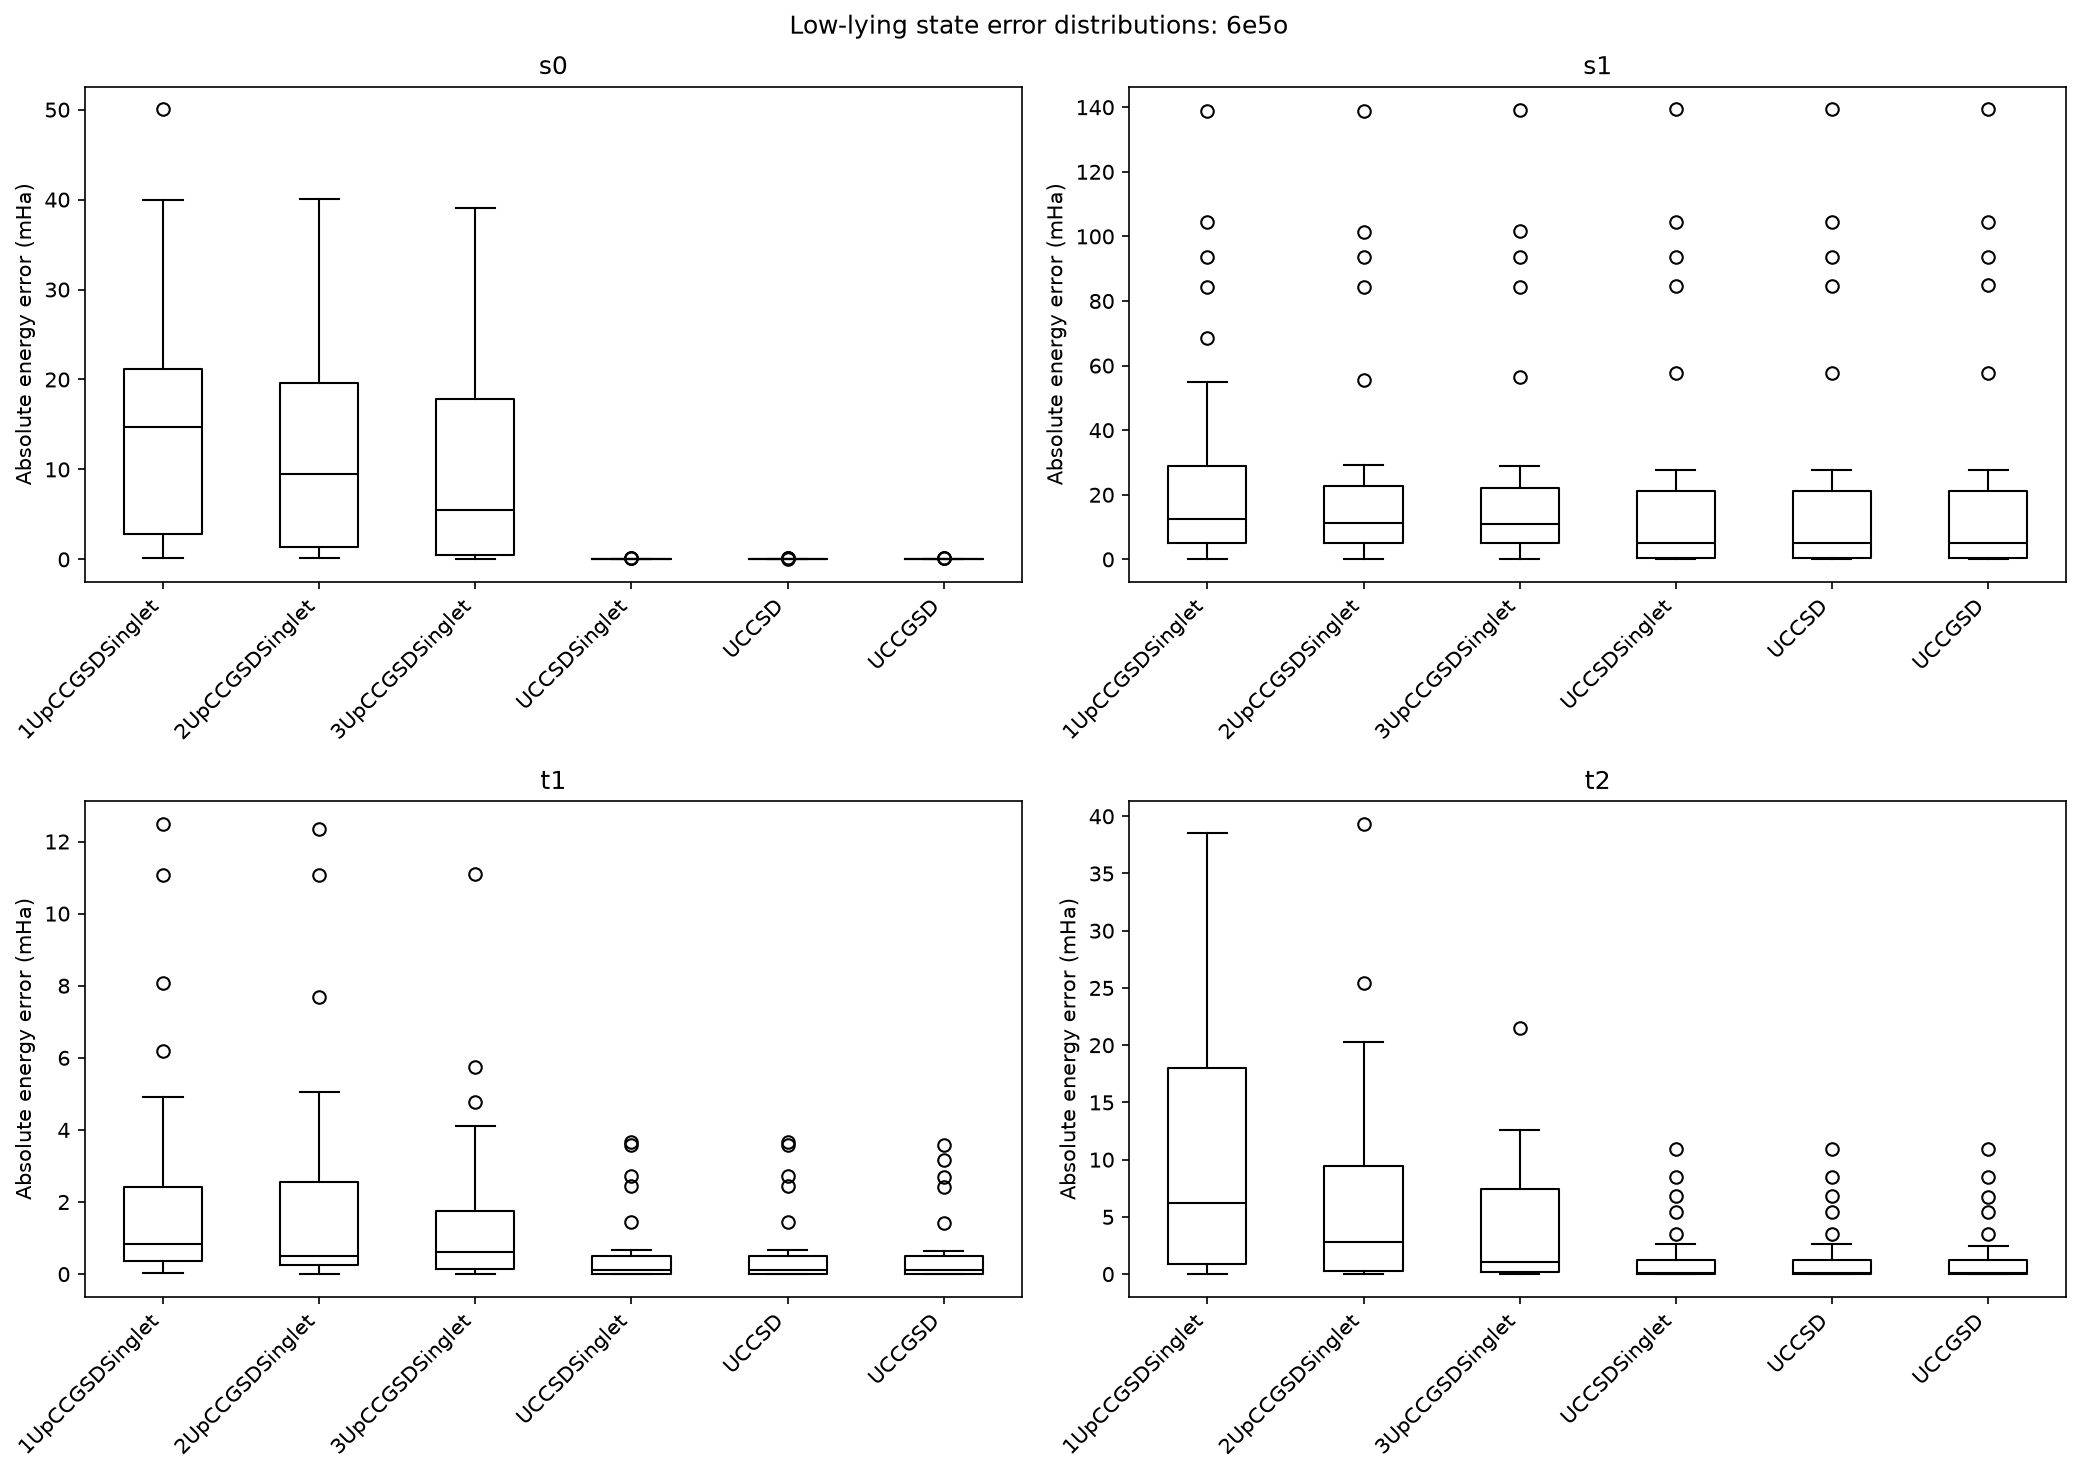
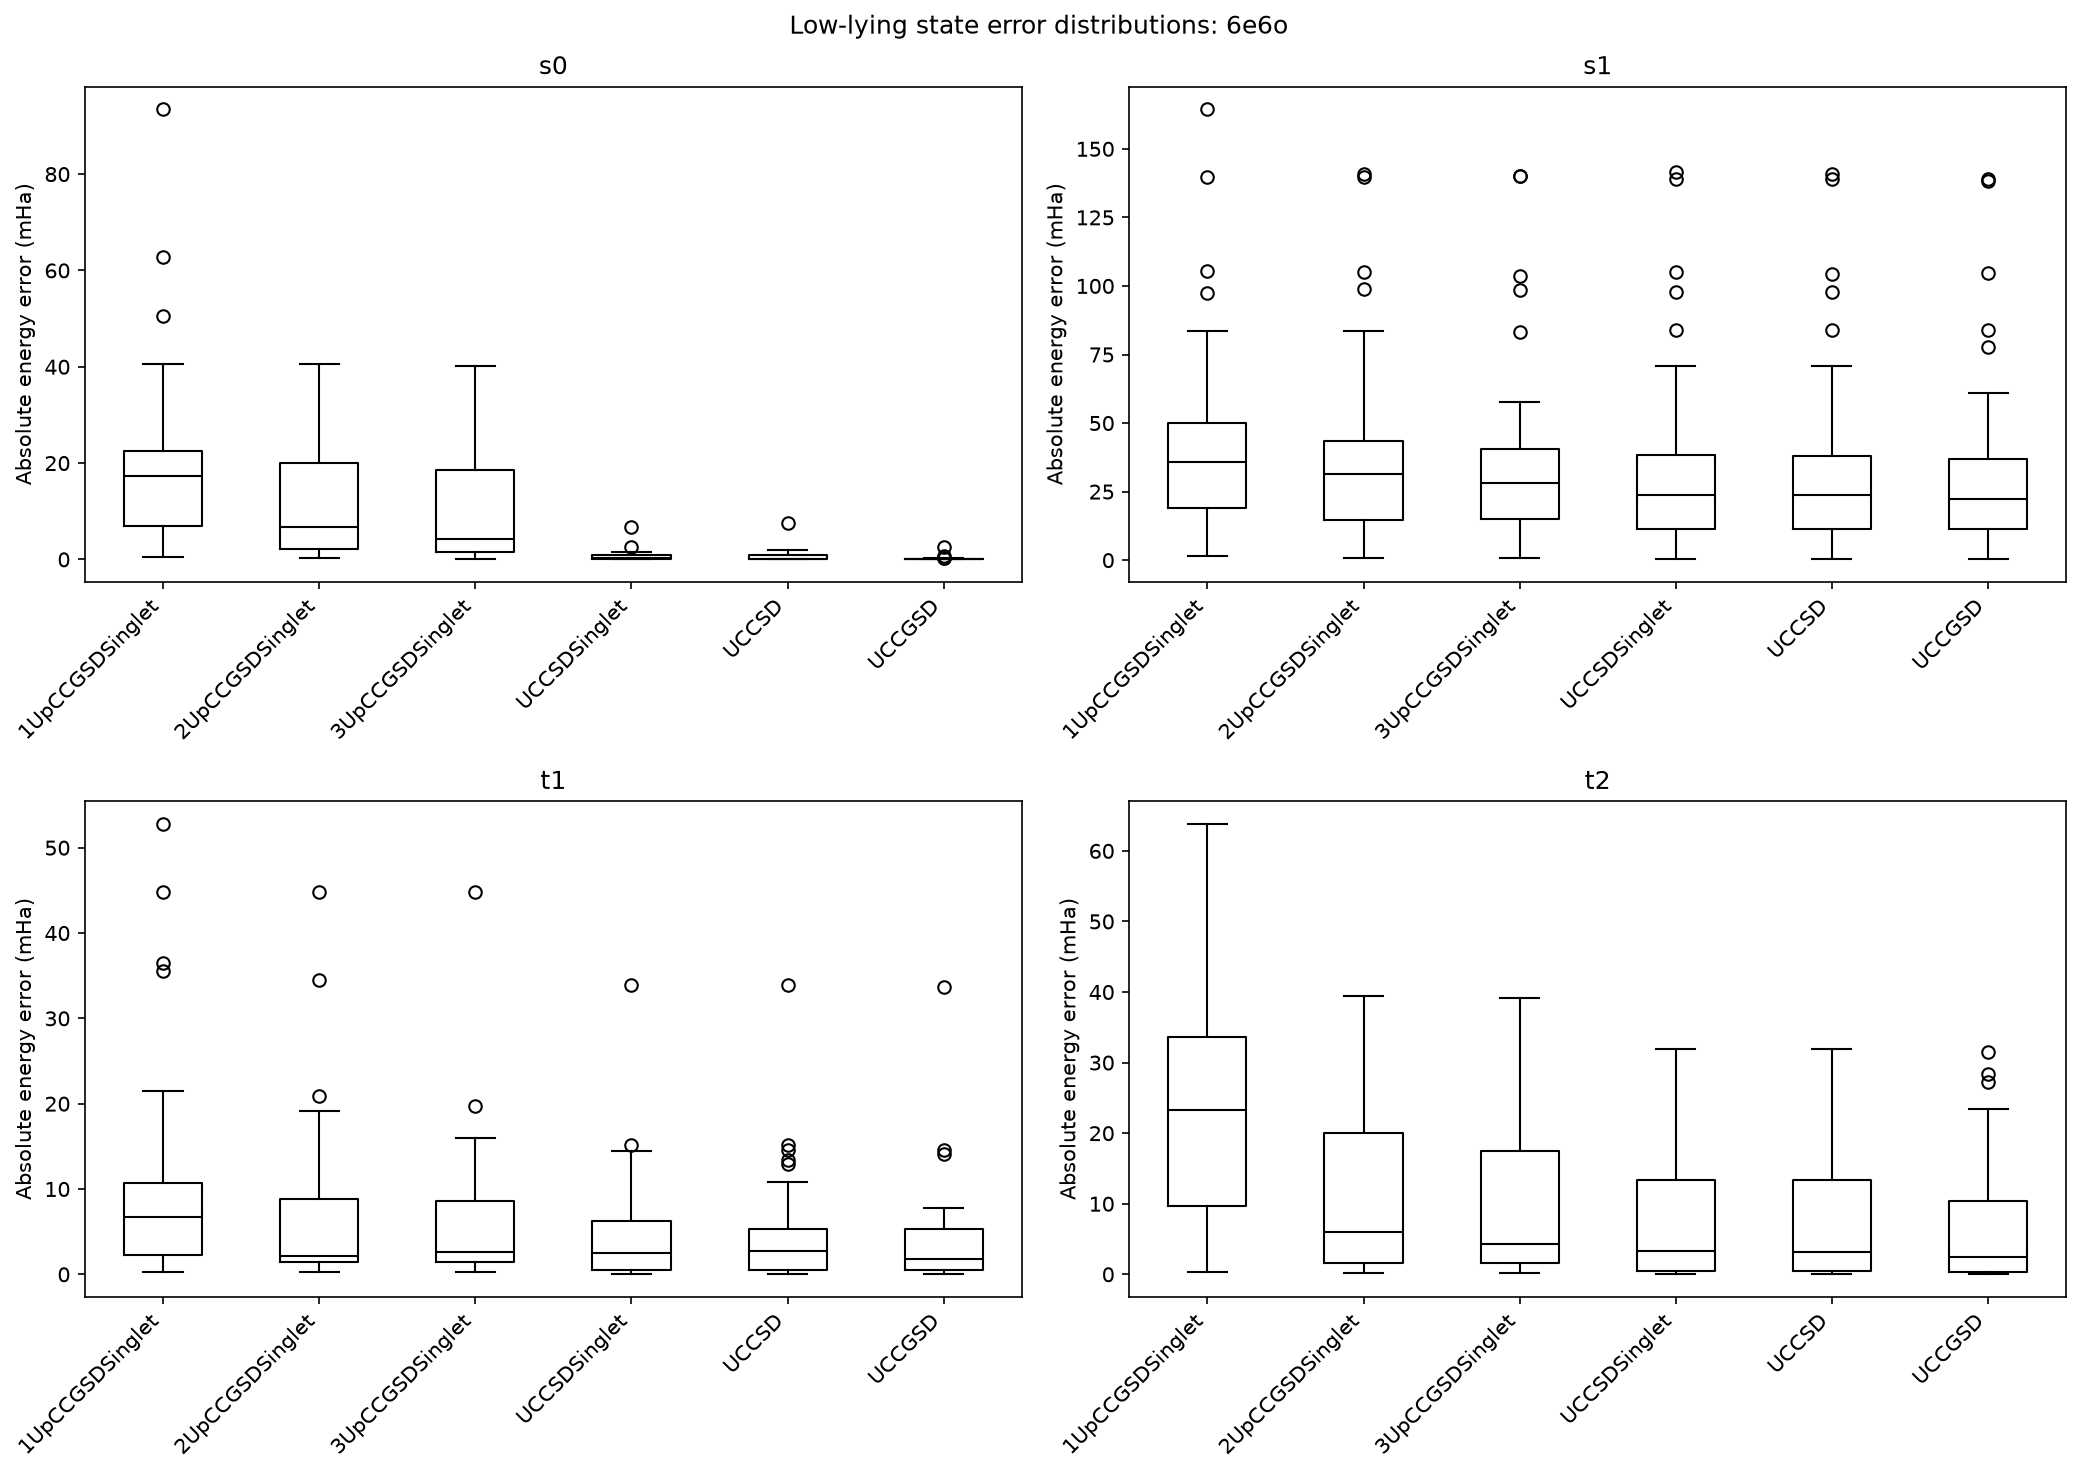

In [ ]:
# Spread of errors
active_spaces = ["2e2o", "2e3o", "4e3o", "4e4o", "4e5o", "6e5o", "6e6o"]
active_space_figs = []
for active_space in active_spaces:
    errors, df_median = show_low_lying_state_errors(active_space, df_sv)

    save_table(df_median, "low_lying_state_errors", f"median_errors_{active_space}")
    figure = plot_error_distribution(errors)
    figure.suptitle(f"Low-lying state error distributions: {active_space}")
    figure.tight_layout()
    active_space_figs.append(figure)
    save_figure(figure, "low_lying_state_errors", f"error_distribution_{active_space}")
show_scrollable_figs(active_space_figs)

## Root reordering

In [ ]:
def get_root_data(row):
    """
    Input a dfSV row and output the root data (wavefunction and energies)
    Output in the form of {root: vector, ...}, for triplets vector is 3xn
    Output both the exact reference and qse one 
    """
    # First solve the H and S matrices to give qse wfn and energies
    num_e, num_o = parse_active_space(row["active_space"])
    singlet_dim, triplet_dim = get_max_states((num_e, num_o))
    dim = {"singlet": singlet_dim, "triplet": triplet_dim}[row["expansion"]]
    qse_sector_energies, qse_wfn, _ = solve_energy_spin_dim(
        row["H"], row["S"], row["S2"], dim
    )

    key = (row["molecule"], row["active_space"], row["ansatz"], row["expansion"])
    # QSE wfn is in the basis of qse operators, multiply by state matrices to get it
    # in the same 2nd quantisation basis
    qse_pvec = qse_state_matrices[key] @ qse_wfn

    if row["expansion"] == "singlet":
        # Reformat the exact wfn from pyscf_pvec
        exact_wavefunctions = {
            f"s{root}": np.asarray(pvec)[None, :]
            for root, pvec in enumerate(row["pyscf_casci_pvec"].values())
        }
        # Get the exact energies 
        exact_energies = {
            f"s{root}": energy
            for root, energy in enumerate(row["pyscf_casci_energies"])
        }
        
        # Only get the s0 and s1 roots wfn and energies
        qse_wavefunctions = {f"q{root}": qse_pvec[:, root][None, :] 
                             for root in range(2)}
        
        qse_energies = {f"q{root}": qse_sector_energies[root] 
                        for root in range(2)}
    elif row["expansion"] == "triplet":
        # Get the exact wavefunctions stacked into a 3xn vector 
        exact_wavefunctions = {
            f"t{root + 1}": np.stack([
                row["pyscf_casci_pvec"][f"{root}_{sector}"]
                for sector in TRIPLET_SECTORS
            ])
            for root in range(len(row["pyscf_casci_energies"]))
        }
        # For energies do the same also
        exact_energies = {
            f"t{root + 1}": energy
            for root, energy in enumerate(row["pyscf_casci_energies"])
        }

        # Take the t1 and t2 roots only 
        qse_wavefunctions = {
            f"q{root}": qse_pvec[:, 3 * root:3 * root + 3].T 
            for root in range(2)
        }
        # Group the triplet energies first 
        triplet_energies, _ = group_triplet_energies(qse_sector_energies[:6])
        qse_energies = {f"q{root}": triplet_energies[root] 
                        for root in range(2)}

    return exact_wavefunctions, qse_wavefunctions, exact_energies, qse_energies


def match_wavefunction_roots(exact_wavefunctions, qse_wavefunctions):
    """
    Input the wavefunction data, exact and qse in a dictionary form
    Use hungarian matching to get the best match based on wavefunction overlap
    """
    exact_roots, qse_roots = list(exact_wavefunctions), list(qse_wavefunctions)
    overlap_matrix = np.empty((len(exact_roots), len(qse_roots)))

    for exact_index, exact_root in enumerate(exact_roots):
        # Loop through all the exact wavefunctions and normalise
        exact_wfn = np.array(exact_wavefunctions[exact_root], dtype=complex, copy=True)
        exact_wfn /= np.linalg.norm(exact_wfn, axis=1, keepdims=True)
        # Loop through all the qse wavefunctions then normalise
        for qse_index, qse_root in enumerate(qse_roots):
            qse_wfn = np.array(qse_wavefunctions[qse_root], dtype=complex, copy=True)
            qse_wfn /= np.linalg.norm(qse_wfn, axis=1, keepdims=True)
            # Build an overlap matrix of the overlap for each wavefunction pairing
            # Linear sum assignment wil maximise this
            overlap_matrix[exact_index, qse_index] = (
                np.linalg.norm(exact_wfn.conj() @ qse_wfn.T) ** 2
                / exact_wfn.shape[0]
                # Divide by number of sectors, ie triplet / 3
            )

    # Return the overlap values 
    root_overlaps = {
        exact_root: dict(zip(qse_roots, overlap_matrix[exact_index]))
        for exact_index, exact_root in enumerate(exact_roots)
    }
    exact_indices, qse_indices = linear_sum_assignment(overlap_matrix, maximize=True)
    root_pairing = dict.fromkeys(exact_roots, np.nan)
    # Fill up the root pairs based on the best match indices
    for exact_index, qse_index in zip(exact_indices, qse_indices):
        root_pairing[exact_roots[exact_index]] = qse_roots[qse_index]
    return root_pairing, root_overlaps


def get_matched_errors(exact_energies, qse_energies, root_pairing):
    """
    Return the errors in mHa based on the best matched roots 
    """
    return {
        root: np.nan if pd.isna(qse_root)
        else 1000 * abs(qse_energies[qse_root] - exact_energies[root])
        for root, qse_root in root_pairing.items()
    }

In [ ]:
# Match the first two physical QSE roots by wavefunction overlap
df_6e6o = df_sv[df_sv["active_space"] == "6e6o"]
wavefunction_match_rows = []

for _, row in df_6e6o.iterrows():
    # For every row get the root data then match based on wavefunction overlap
    exact_wavefunctions, qse_wavefunctions, exact_energies, qse_energies = (
        get_root_data(row)
    )
    root_pairing, root_overlaps = match_wavefunction_roots(exact_wavefunctions, qse_wavefunctions)
    matched_errors = get_matched_errors(exact_energies, qse_energies, root_pairing)

    # Add in a new row entry with the relevant data
    for state, exact_energy in exact_energies.items():
        qse_root = root_pairing[state]
        qse_energy = np.nan if pd.isna(qse_root) else qse_energies[qse_root]

        wavefunction_match_rows.append({
            "molecule": row["molecule"],
            "ansatz": row["ansatz"],
            "expansion": row["expansion"],
            "state": state,
            "qse_root": qse_root,
            "exact_energy": exact_energy,
            "qse_energy": qse_energy,
            "q0_overlap": root_overlaps[state]["q0"],
            "q1_overlap": root_overlaps[state]["q1"],
            "index_error_mHa": row[f"{state}_error"],
            "matched_error_mHa": matched_errors[state],
        })

df_wavefunction_matches = pd.DataFrame(wavefunction_match_rows)

In [ ]:
# Compare index and wavefunction-matched errors for the low-lying states
# Separated by anastz and state
comparison_rows = []

for ansatz in ANSATZ_FUNCTIONS:
    df_ansatz = df_wavefunction_matches[df_wavefunction_matches["ansatz"] == ansatz]

    for state in ("s0", "s1", "t1", "t2"):
        df_state = df_ansatz[df_ansatz["state"] == state]
        matched_errors = df_state["matched_error_mHa"].dropna()

        comparison_rows.append({
            "ansatz": ansatz,
            "state": state,
            "index_median_error_mHa": df_state["index_error_mHa"].median(),
            "matched_median_error_mHa": matched_errors.median(),
            "num_matched": len(matched_errors),
            "percentage_matched": 100 * len(matched_errors) / 28,
        })

df_wavefunction_match_summary = pd.DataFrame(comparison_rows)
display(df_wavefunction_match_summary)

,ansatz,state,index_median_error_mHa,matched_median_error_mHa,num_matched,percentage_matched
0,1UpCCGSDSinglet,s0,17.387874,17.387874,28,100.000000
1,1UpCCGSDSinglet,s1,35.931121,31.316587,20,71.428571
2,1UpCCGSDSinglet,t1,6.696192,6.696192,28,100.000000
3,1UpCCGSDSinglet,t2,23.316927,18.929798,25,89.285714
4,2UpCCGSDSinglet,s0,6.709098,6.709098,28,100.000000
5,2UpCCGSDSinglet,s1,31.392959,21.417735,21,75.000000
6,2UpCCGSDSinglet,t1,2.152461,2.202429,28,100.000000
7,2UpCCGSDSinglet,t2,5.961244,4.687349,25,89.285714
8,3UpCCGSDSinglet,s0,4.139297,4.139297,28,100.000000
9,3UpCCGSDSinglet,s1,28.234018,21.674791,22,78.571429


In [ ]:
# A clear example where the first QSE excited root has s2 character
df_root_reordering_example = df_wavefunction_matches.query(
    "molecule == 'Pyrrole' and ansatz == 'UCCSD' and expansion == 'singlet' "
    "and state in ['s0', 's1', 's2']"
)
display(df_root_reordering_example)

,molecule,ansatz,expansion,state,qse_root,exact_energy,qse_energy,q0_overlap,q1_overlap,index_error_mHa,matched_error_mHa
2982,Pyrrole,UCCSD,singlet,s0,q0,-206.277674,-206.277583,9.999247e-01,1.511090e-13,0.091293,0.091293
2983,Pyrrole,UCCSD,singlet,s1,NaN,-205.988082,NaN,5.097244e-09,4.135788e-06,104.410412,NaN
2984,Pyrrole,UCCSD,singlet,s2,q1,-205.883871,-205.883672,1.979647e-15,9.997490e-01,9.623687,0.199015


## Spin Contamination

In [ ]:
def get_bad_spin_root_data(active_space, df_sv, threshold):
    """
    For one active space from df_sv, return the 
    1) number of spin contaminated states above a threshold with qse root number
    2) mean spin contamination for each of the low lying states (in a table)
    
    """
    df_active = df_sv[df_sv["active_space"] == active_space]
    bad_spin_roots = {}
    mean_spin_contamination = {}

    for ansatz in ANSATZ_FUNCTIONS:
        df_active_ansatz = df_active[df_active["ansatz"] == ansatz]
        bad_spin_roots[ansatz] = {}
        mean_spin_contamination[ansatz] = {}

        for expansion in ("singlet", "triplet"):
            df_expansion = df_active_ansatz[df_active_ansatz["expansion"] == expansion]
            # Reference that one column and stack, make spin_values num_molecules x num_roots
            spin_values = np.stack(df_expansion["full_spin_contamination"])
            start = 0 if expansion == "singlet" else 1
            prefix = "s" if expansion == "singlet" else "t"
            # Save the spin contamination as a dictionary with labeled root number
            # For first plot, only save those values above fixed threshold
            root_data = {
                f"{prefix}{root + start}": values[values > threshold]
                for root, values in enumerate(spin_values.T)
            }
            # Separate by ansatz and singlet/triplet
            bad_spin_roots[ansatz][expansion] = root_data

            # For low lying states, update the mean error for all roots
            low_lying_states = ("s0", "s1") if expansion == "singlet" else ("t1", "t2")
            mean_spin_contamination[ansatz].update({
                state: float(
                    np.mean(spin_values[:, root])
                    ) 
                    # For t2 missing states (2e2o)
                    if root < spin_values.shape[1] else np.nan
                    for root, state in enumerate(low_lying_states)
            })
    # Returns both as a dictionary
    return bad_spin_roots, mean_spin_contamination


ValueError: need at least one array to stack

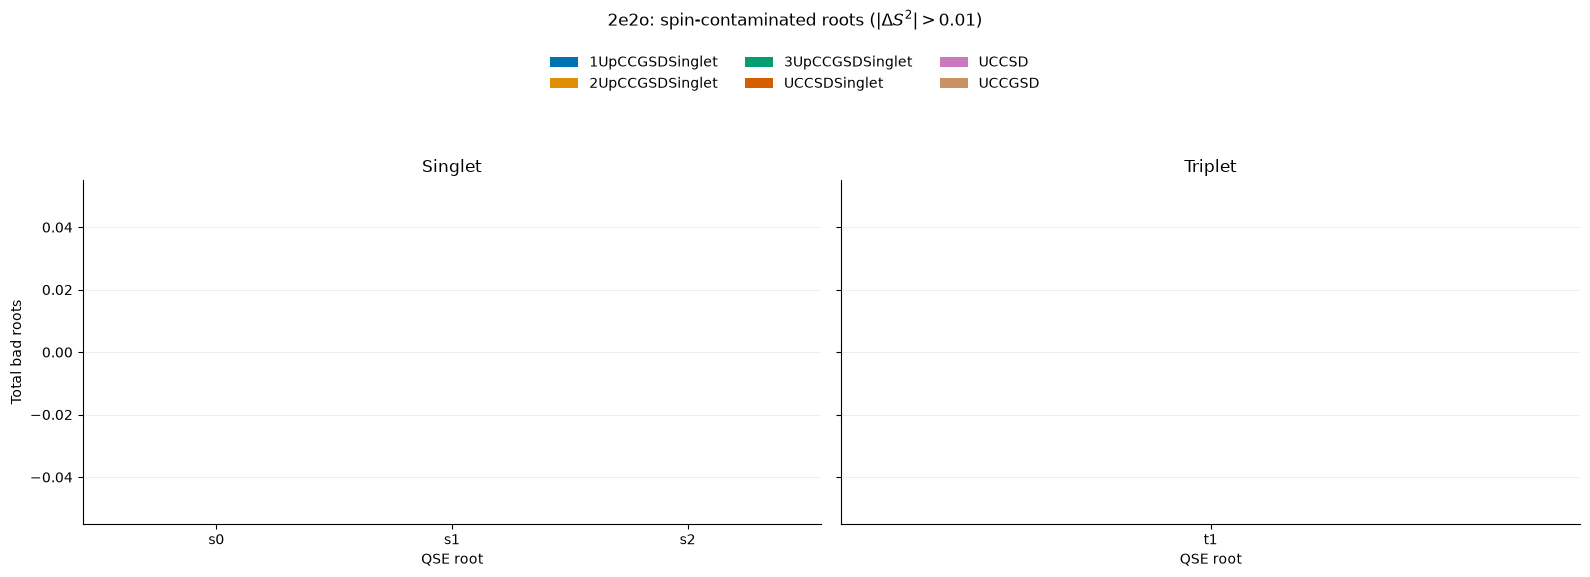

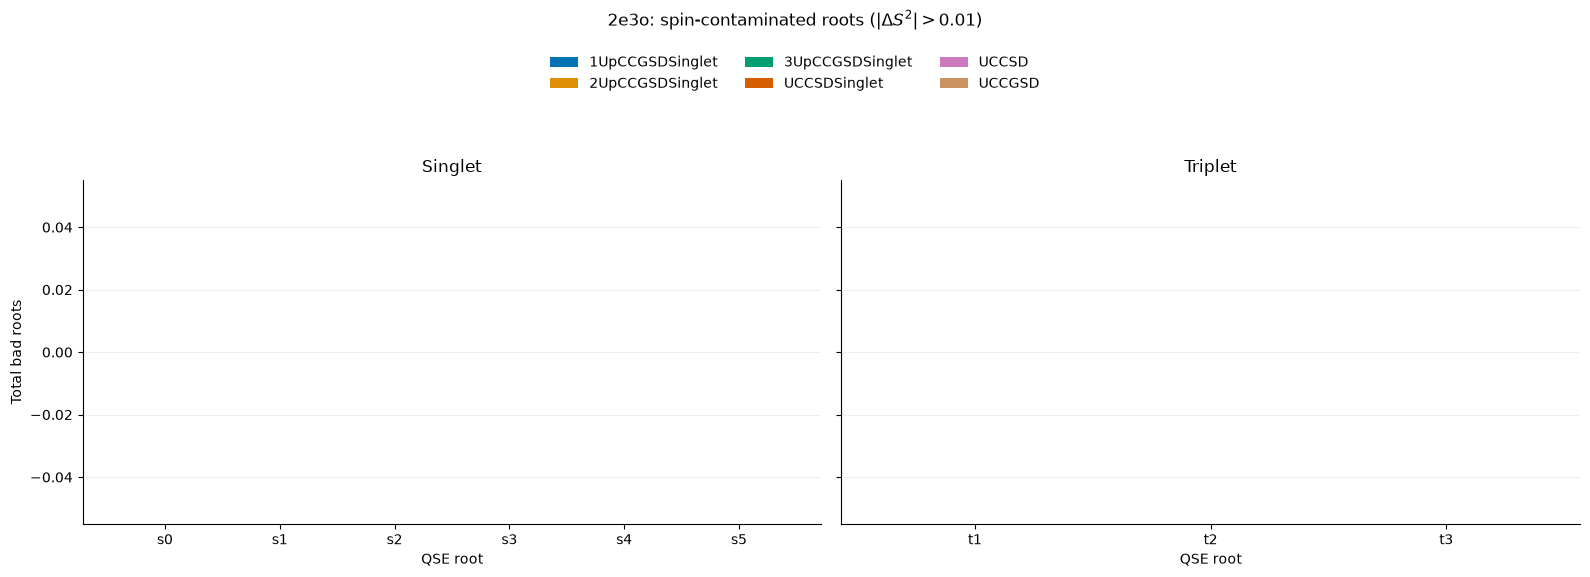

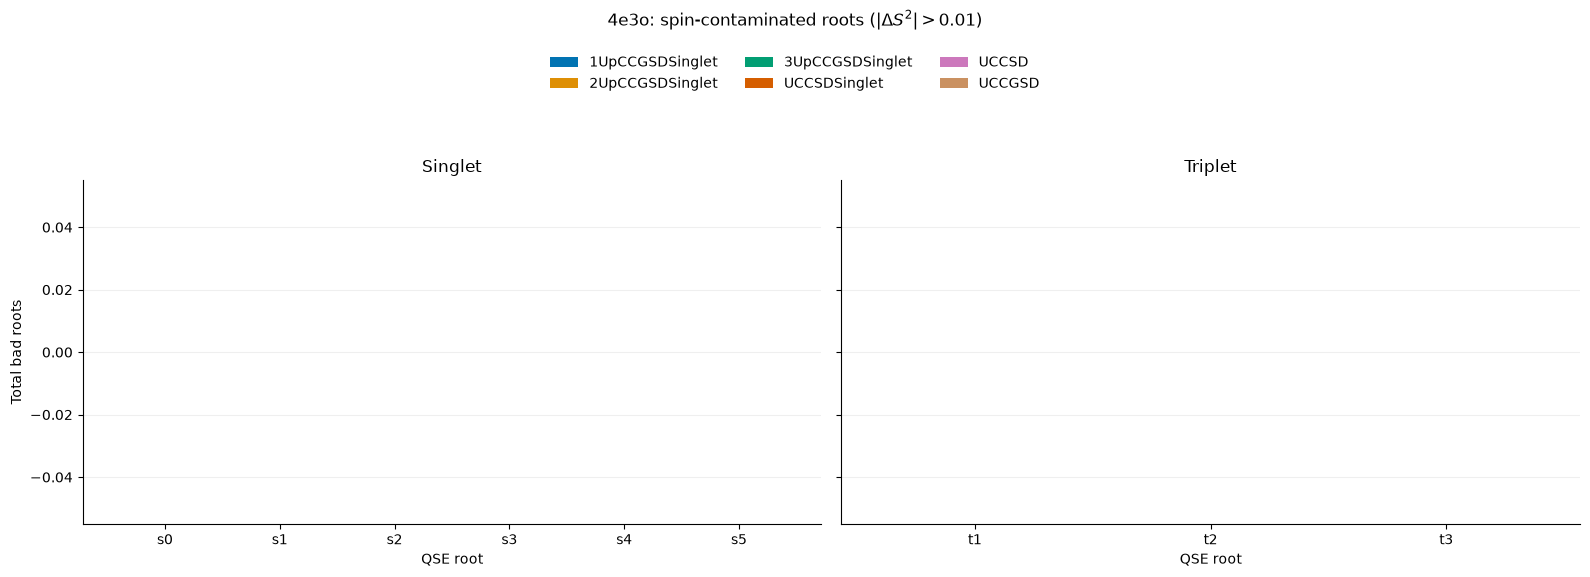

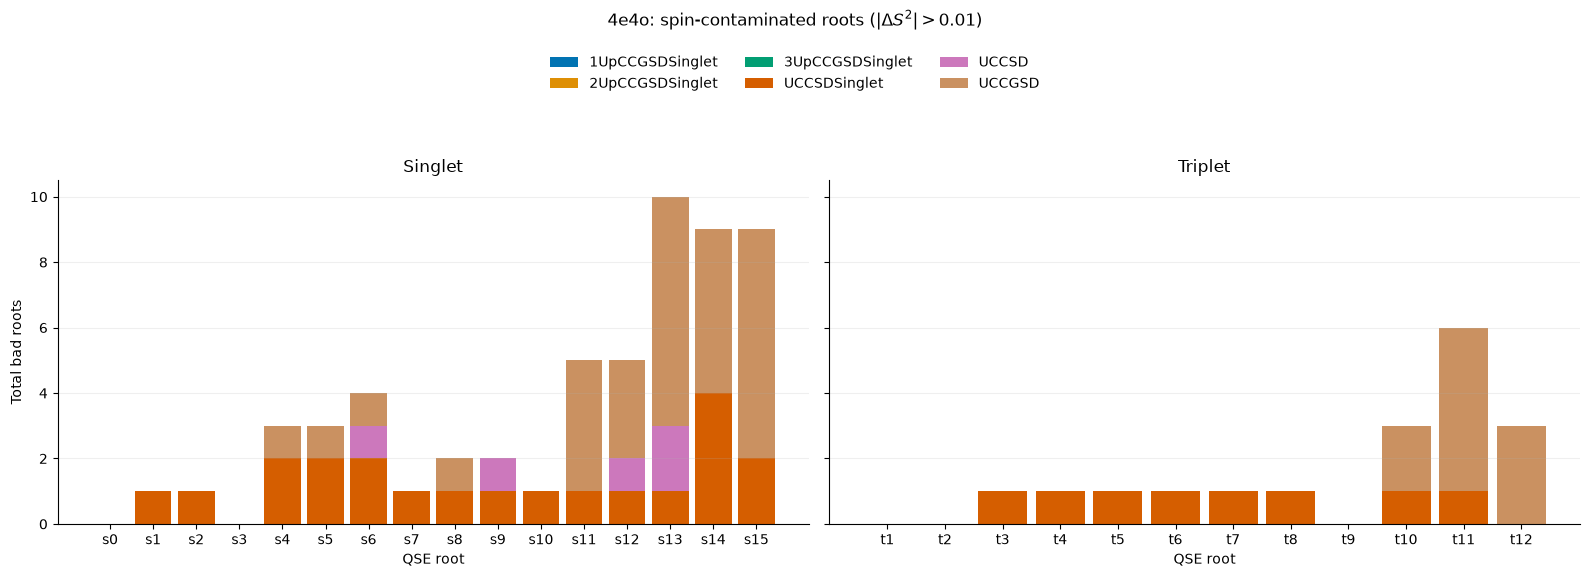

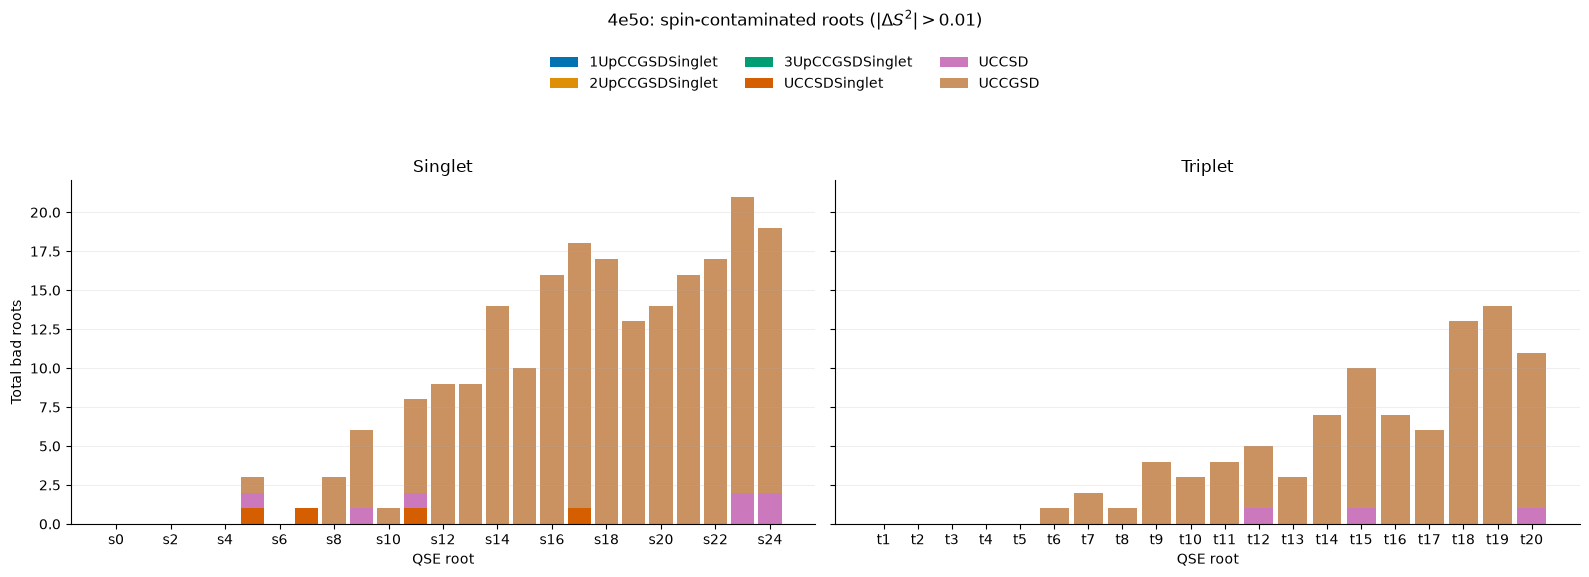

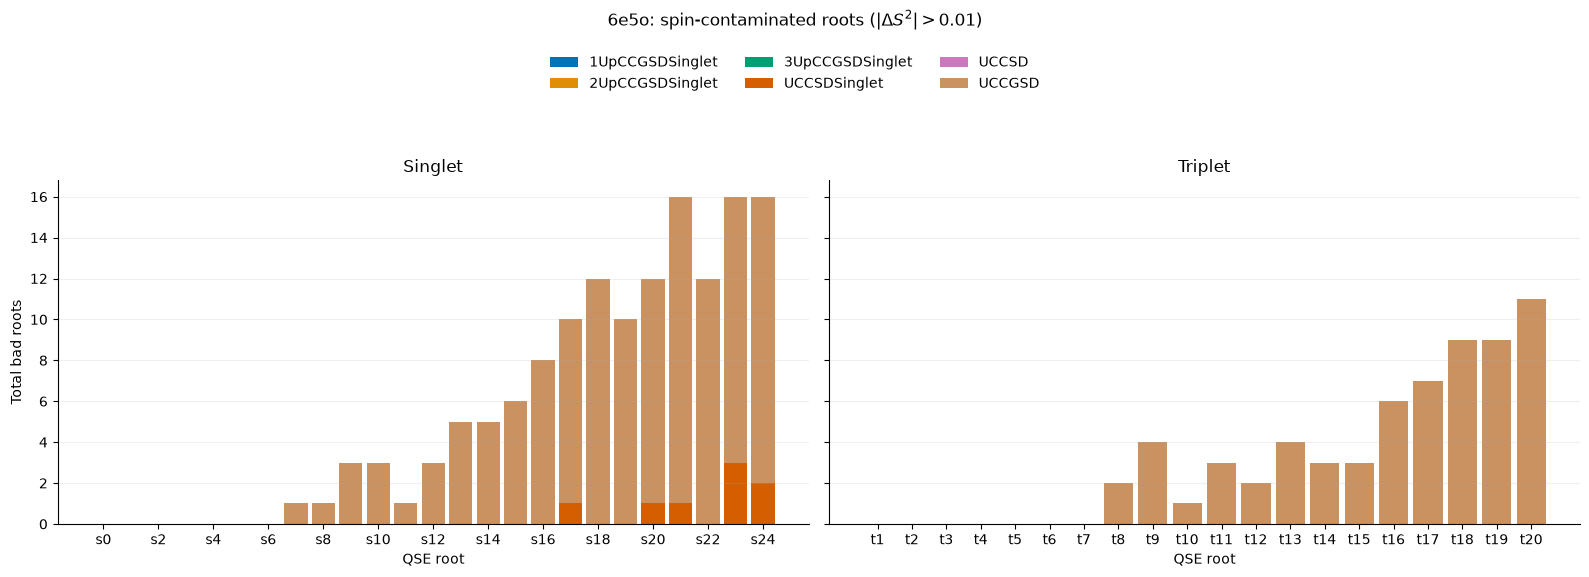

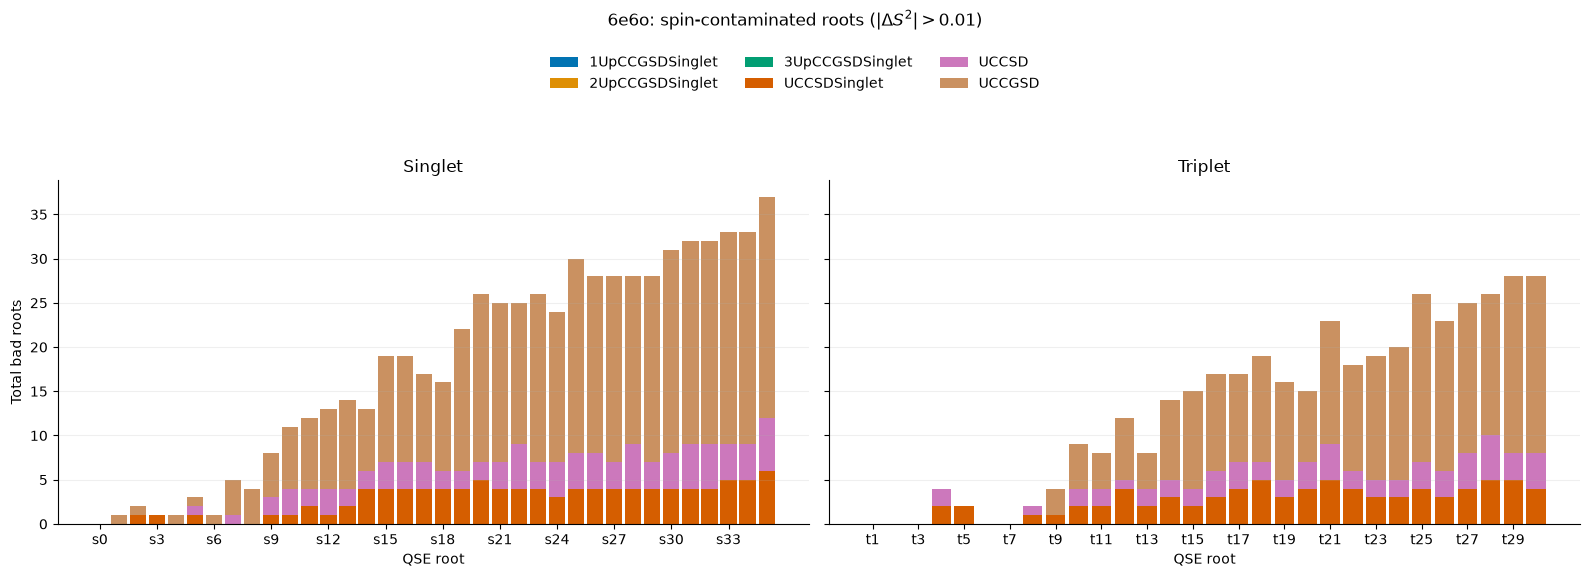

In [ ]:
# Build, save and display the bad-root analysis for every active space
bad_spin_roots_by_space = {}
mean_spin_contamination_by_space = {}
mean_spin_tables = {}
spin_contamination_figures = []

BAD_SPIN_THRESHOLD = 0.01

for active_space in ACTIVE_SPACE_ORDER:
    bad_spin_roots, mean_spin_contamination = get_bad_spin_root_data(active_space, df_sv, BAD_SPIN_THRESHOLD)
    df_mean = pd.DataFrame(mean_spin_contamination).T[["s0", "s1", "t1", "t2"]]

    bad_spin_roots_by_space[active_space] = bad_spin_roots
    mean_spin_contamination_by_space[active_space] = mean_spin_contamination
    mean_spin_tables[active_space] = df_mean

    figure = plot_bad_spin_roots(bad_spin_roots, active_space, BAD_SPIN_THRESHOLD)
    save_figure(figure, "spin_contamination", f"bad_spin_roots_{active_space}")
    spin_contamination_figures.append(figure)

df_mean_spin_contamination = pd.concat(mean_spin_tables, names=["active_space"])
save_table(df_mean_spin_contamination, "spin_contamination", "mean_low_lying_spin_contamination")
display(df_mean_spin_contamination)
show_scrollable_figs(spin_contamination_figures)


In [ ]:
"""
Compare UCCSD and UCCSDSinglet effect of trotter steps
Re run VQE from the canonical qibo molecule with different trotter steps
"""

active_space = "4e4o"
trotter_ladder = (1, 2, 4, 8, 16, 32)
trotter_ansatzes = {
    "UCCSDSinglet": Ansatz_UCCSDSinglet,
    "UCCSD": Ansatz_UCCSD,
}

trotter_spin_rows = []

for molecule_name in MOLECULE_NAMES:
    molecule = load_qibo_mol(molecule_name, active_space)

    for ansatz_name, ansatz_function in trotter_ansatzes.items():
        for trotter_steps in trotter_ladder:
            ansatz = ansatz_function(molecule, trotter_steps=trotter_steps)
            vqe_energy, _, final_circuit = ansatz.run_vqe(StateVectorProtocol(), method="L-BFGS-B", fast=True)
            vqe_state = final_circuit().state()

            trotter_spin_rows.append({
                "molecule": molecule_name,
                "active_space": active_space,
                "ansatz": ansatz_name,
                "trotter_steps": trotter_steps,
                "num_parameters": len(ansatz.param_names),
                "circuit_depth": final_circuit.depth,
                "vqe_energy_Ha": float(vqe_energy),
                "spin_contamination": get_vqe_spin_contamination(vqe_state, active_space),
            })

df_trotter_spin_results = pd.DataFrame(trotter_spin_rows)
df_trotter_spin_mean = (
    df_trotter_spin_results.groupby(["ansatz", "trotter_steps"], sort=False)
    .agg(
        num_molecules=("molecule", "nunique"),
        num_parameters=("num_parameters", "first"),
        circuit_depth=("circuit_depth", "first"),
        mean_spin_contamination=("spin_contamination", "mean"),
    )
    .reset_index()
)

save_table(df_trotter_spin_results, "spin_contamination", "uccsd_trotter_spin_results_4e4o")
save_table(df_trotter_spin_mean, "spin_contamination", "uccsd_trotter_spin_mean_4e4o")
display(df_trotter_spin_mean)


,ansatz,trotter_steps,num_molecules,num_parameters,circuit_depth,mean_spin_contamination
0,UCCSDSinglet,1,28,14,2181,2.943113e-06
1,UCCSDSinglet,2,28,14,4370,6.894982e-07
2,UCCSDSinglet,4,28,14,8748,1.690743e-07
3,UCCSDSinglet,8,28,14,17504,4.205176e-08
4,UCCSDSinglet,16,28,14,35016,1.049051e-08
5,UCCSDSinglet,32,28,14,70040,2.620550e-09
6,UCCSD,1,28,26,1951,1.207535e-08
7,UCCSD,2,28,26,3939,1.370162e-08
8,UCCSD,4,28,26,7915,2.079582e-08
9,UCCSD,8,28,26,15867,1.926998e-08


## Projection of Exact Roots


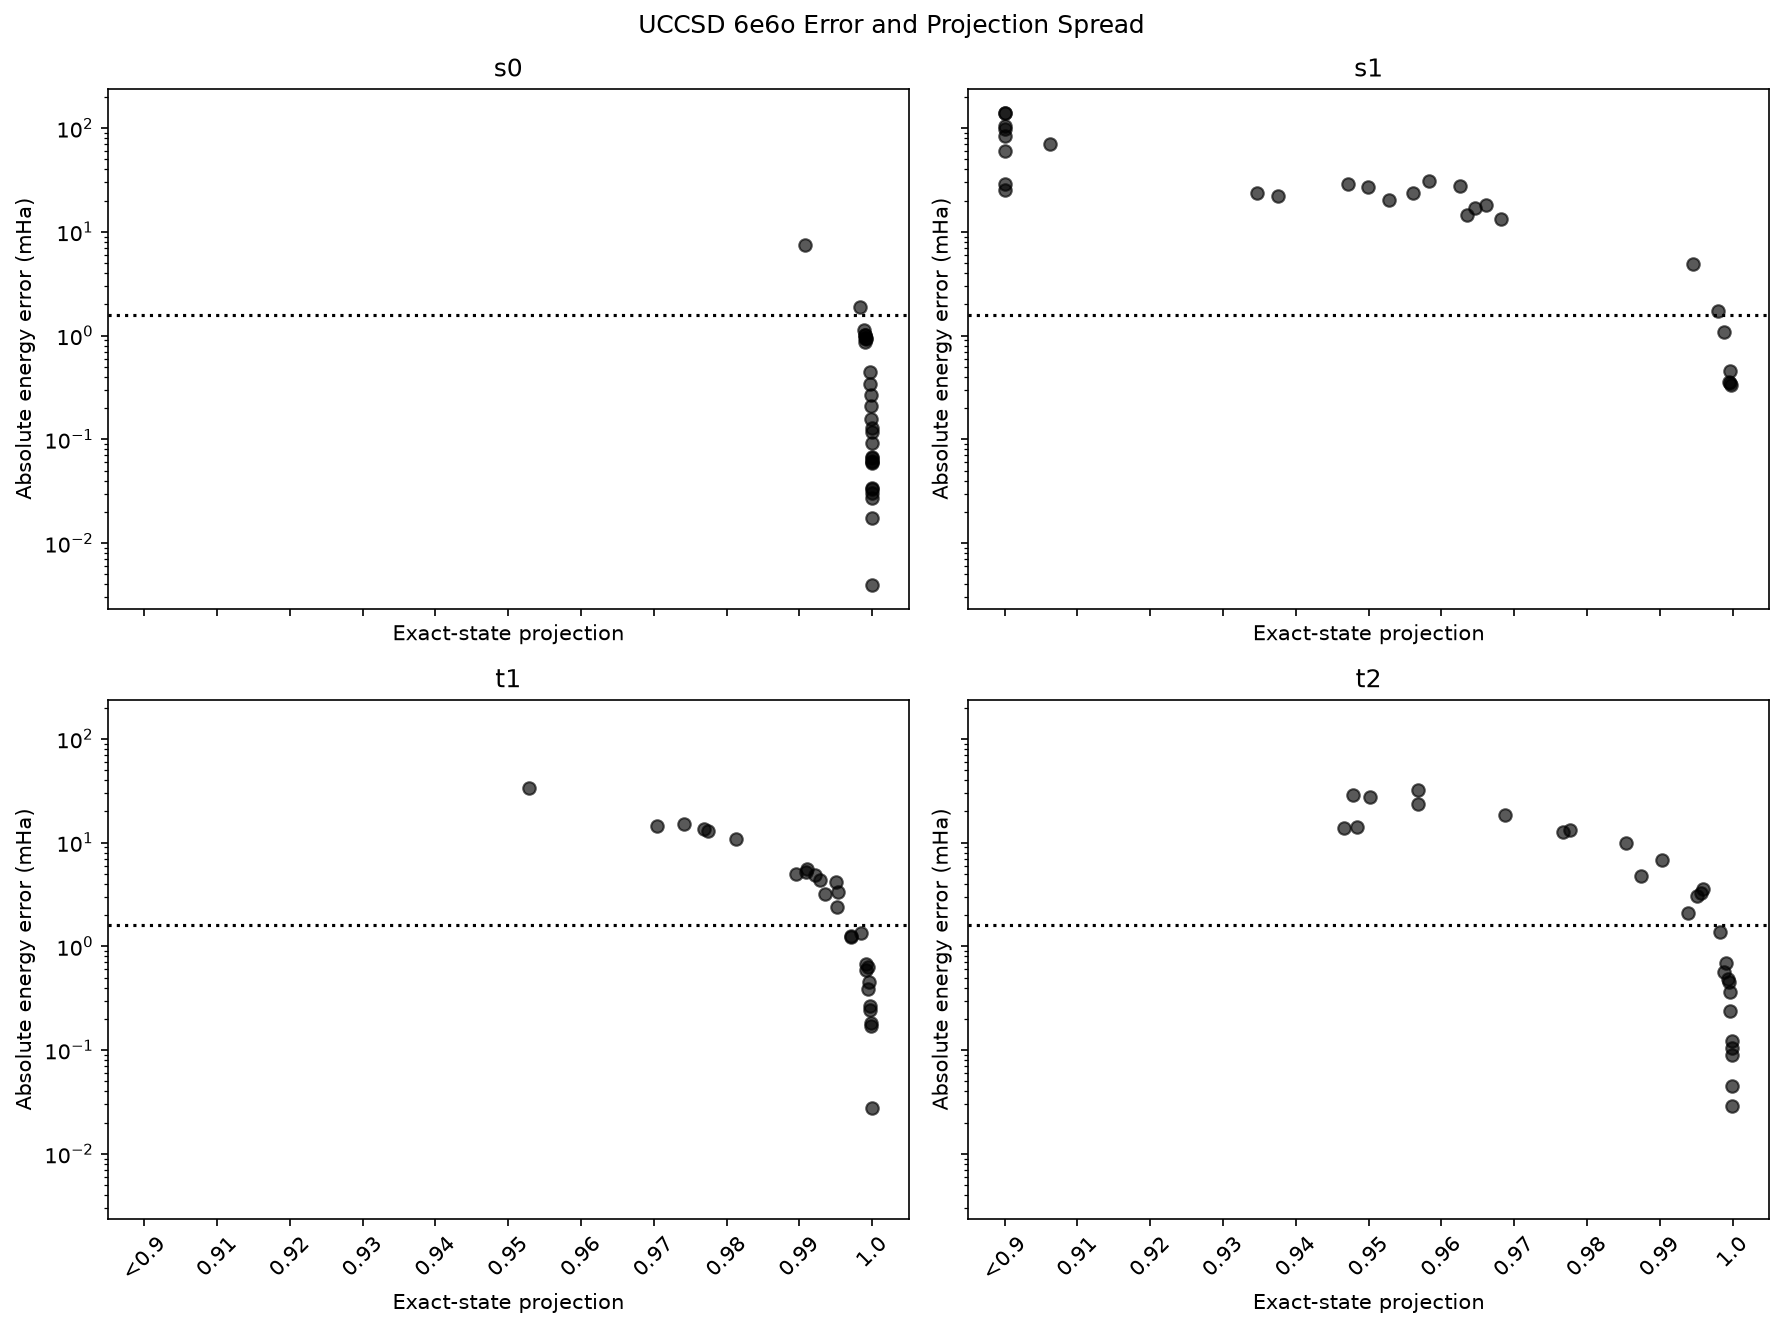

In [ ]:
df_projection = df_sv[
    (df_sv["active_space"] == "6e6o")
    & (df_sv["ansatz"] == "UCCSD")
]

projection_error_data = {}
for state in ("s0", "s1", "t1", "t2"):
    expansion = "singlet" if state.startswith("s") else "triplet"
    df_state = df_projection[df_projection["expansion"] == expansion]
    projection_error_data[state] = list(zip(
        np.maximum(df_state[f"{state}_projection"], 0.9),
        df_state[f"{state}_error"],
    ))

projection_error_figure = plot_projection_error(projection_error_data)
save_figure(projection_error_figure, "projection_error", "projection_error_6e6o_UCCSD")
show_scrollable_figs([projection_error_figure])


## Active Space Scaling


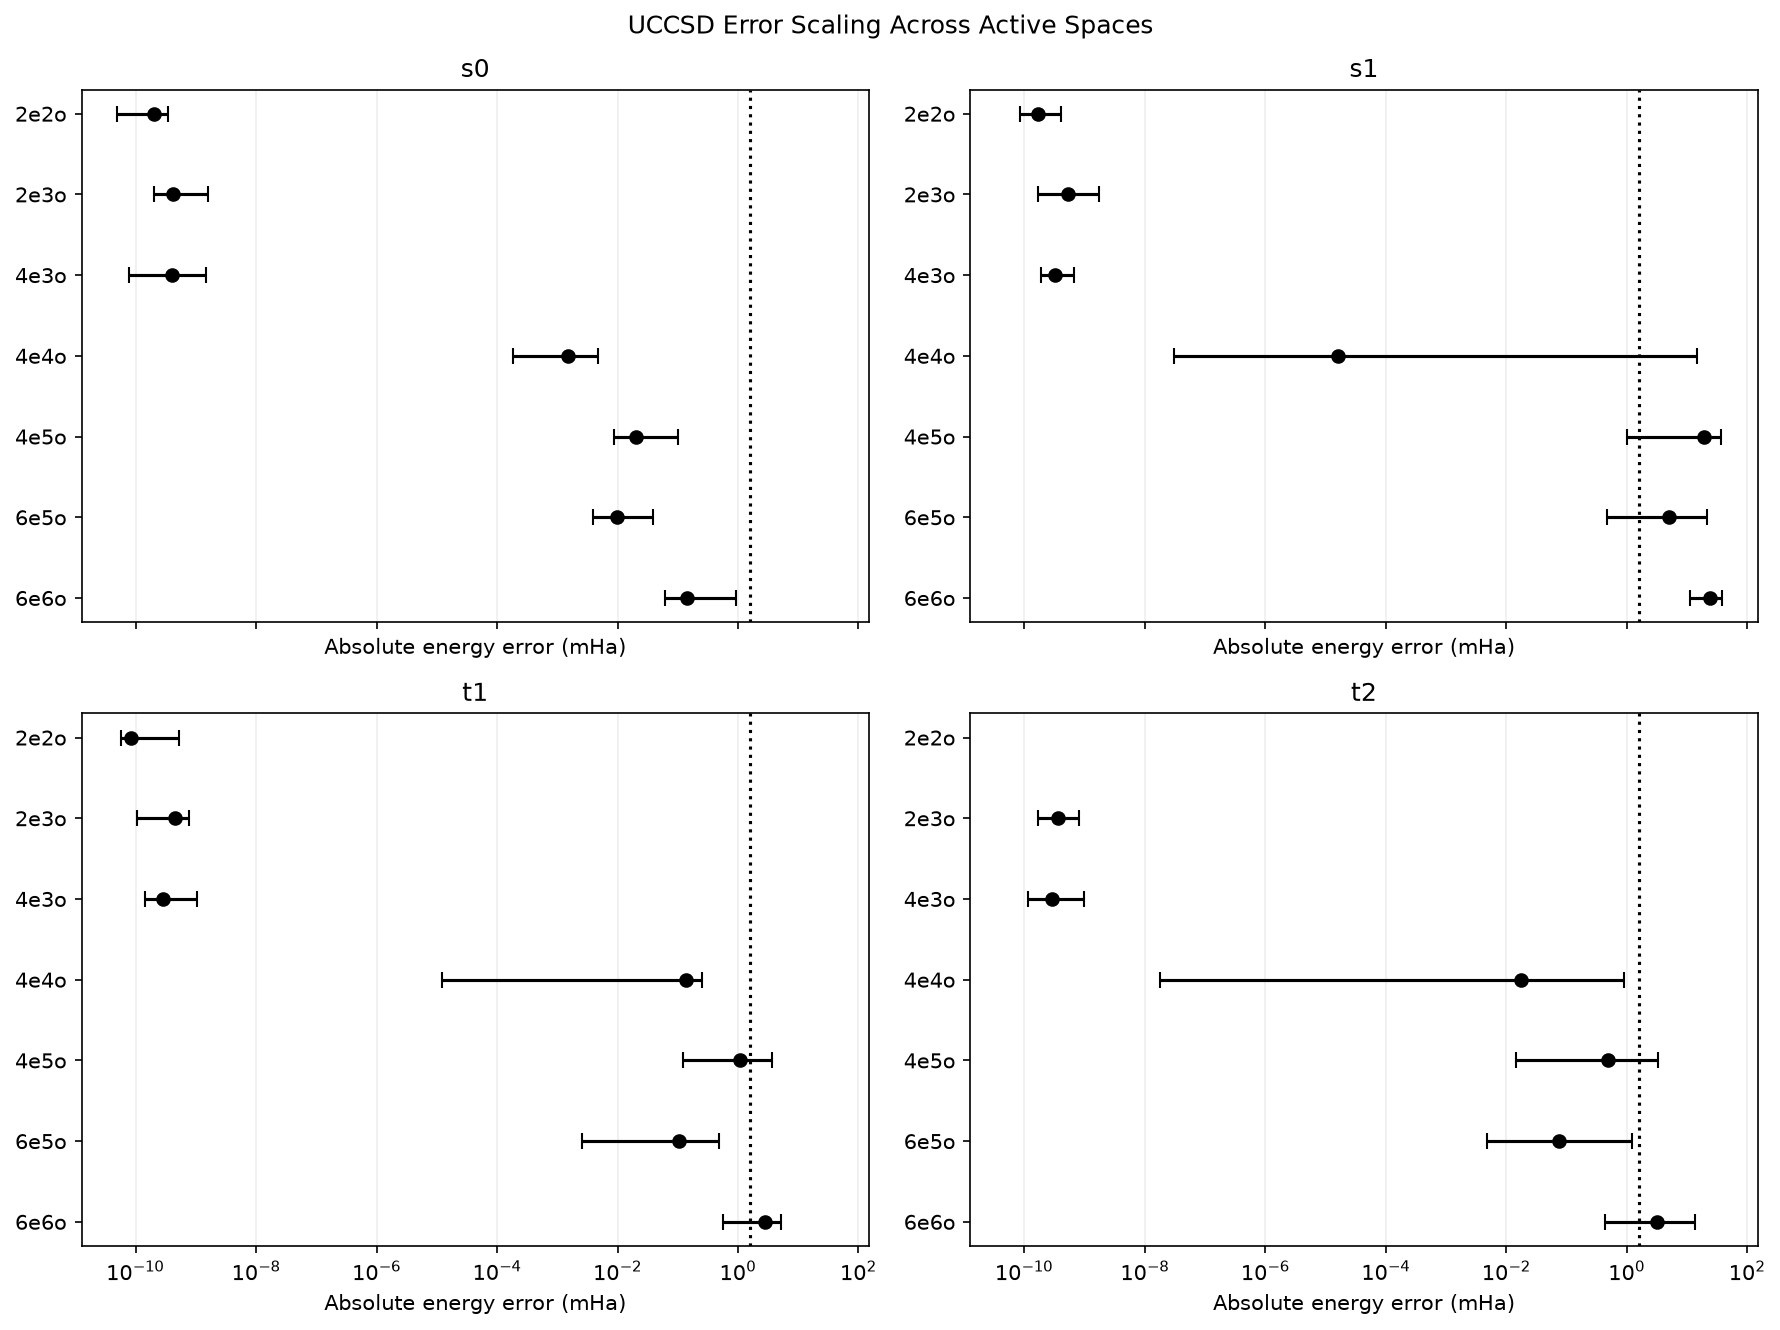

In [ ]:
df_uccsd = df_sv[df_sv["ansatz"] == "UCCSD"]
active_spaces = ACTIVE_SPACE_ORDER[:ACTIVE_SPACE_ORDER.index("6e6o") + 1]

uccsd_error_data = {}
for active_space in active_spaces:
    df_active = df_uccsd[df_uccsd["active_space"] == active_space]
    uccsd_error_data[active_space] = {}

    for state in ("s0", "s1", "t1", "t2"):
        expansion = "singlet" if state.startswith("s") else "triplet"
        df_state = df_active[df_active["expansion"] == expansion]
        uccsd_error_data[active_space][state] = df_state[f"{state}_error"].to_numpy()

active_space_error_figure = plot_active_space_error_iqr(uccsd_error_data)
save_figure(active_space_error_figure, "active_space_scaling", "uccsd_low_lying_error_iqr")
show_scrollable_figs([active_space_error_figure])
